# EDA: Filtered Beauty + Clothing

This notebook analyzes the final Beauty target-domain and Clothing source-domain
datasets used for cross-category recommendation experiments. It uses disk-backed
SQLite so large JSONL inputs do not need to fit in memory.

Beauty is split into train, validation, and test sets. Clothing is used as
source-domain training signal only. The notebook reports dataset size, user overlap,
sparsity, metadata coverage, image availability, warm/cold diagnostics, and
cross-category transfer indicators.

### Filtering method

1. Keep reviews in the configured 2021-2022 timestamp window.
2. Apply no minimum-rating filter.
3. Across both categories, deduplicate `(user_id, parent_asin)` and retain the
   most recent review.
4. Keep users with at least 5 Beauty interactions.
5. Define Beauty train through `2022-08-01 00:00:00 UTC`; validation continues
   through `2022-10-01 00:00:00 UTC`; later Beauty interactions are test.
6. Keep only users visible in Beauty train.
7. Add all in-window Clothing interactions from those Beauty-train users to
   training, with no Clothing time split.
8. Remove Clothing items with fewer than 3 selected Clothing interactions.

> Important: selected Clothing interactions are used as source-domain training
> signal and are not split temporally in the same way as Beauty interactions.

### Runtime

The four raw inputs total roughly 55 GB. A first full run can take hours and
create a multi-GB SQLite cache. For a smoke run, set:

```bash
export YC_CROSS_EDA_MAX_REVIEW_ROWS_PER_FILE=100000
export YC_CROSS_EDA_MAX_META_ROWS_PER_FILE=100000
```

Unset the caps for full-file results.


In [1]:
from __future__ import annotations

import csv
import gc
import json
import math
import os
import sqlite3
import textwrap
import time
from collections import Counter
from pathlib import Path
from typing import Any, Iterator, Sequence

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle


def env_bool(name: str, default: bool) -> bool:
    value: str | None = os.environ.get(name)
    if value is None:
        return default
    return value.strip().lower() in {"1", "true", "yes", "y", "on"}


def env_optional_int(name: str) -> int | None:
    value: str | None = os.environ.get(name)
    if value is None or not value.strip():
        return None
    return int(value)


PROJECT_ROOT: Path = Path(
    os.environ.get(
        "YC_CROSS_EDA_PROJECT_ROOT",
        str(Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()),
    )
)
DATASET_DIR: Path = Path(
    os.environ.get("YC_CROSS_EDA_DATASET_DIR", str(PROJECT_ROOT / "dataset"))
)
OUTPUT_DIR: Path = Path(
    os.environ.get(
        "YC_CROSS_EDA_OUTPUT_DIR",
        str(PROJECT_ROOT / "eda_outputs_yc_filtered_beauty_clothing"),
    )
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEAUTY_CATEGORY: str = "Beauty_and_Personal_Care"
CLOTHING_CATEGORY: str = "Clothing_Shoes_and_Jewelry"
CATEGORIES: tuple[str, str] = (BEAUTY_CATEGORY, CLOTHING_CATEGORY)
CATEGORY_LABELS: dict[str, str] = {
    BEAUTY_CATEGORY: "Beauty",
    CLOTHING_CATEGORY: "Clothing",
}

REVIEW_PATHS: dict[str, Path] = {
    BEAUTY_CATEGORY: DATASET_DIR / "Beauty_and_Personal_Care.jsonl",
    CLOTHING_CATEGORY: DATASET_DIR / "Clothing_Shoes_and_Jewelry.jsonl",
}
META_PATHS: dict[str, Path] = {
    BEAUTY_CATEGORY: DATASET_DIR / "meta_Beauty_and_Personal_Care.jsonl",
    CLOTHING_CATEGORY: DATASET_DIR / "meta_Clothing_Shoes_and_Jewelry.jsonl",
}

DB_PATH: Path = OUTPUT_DIR / "yc_filtered_beauty_clothing.sqlite"
FILTER_MANIFEST_PATH: Path = OUTPUT_DIR / "filtering_manifest.json"
METADATA_MANIFEST_PATH: Path = OUTPUT_DIR / "metadata_manifest.json"

START_DATE: str = "2021-01-01"
END_DATE: str = "2022-12-31"
TRAIN_END_DATE: str = "2022-08-01"
VALID_END_DATE: str = "2022-10-01"

USER_MIN_BEAUTY_INTERACTIONS: int = int(
    os.environ.get("YC_CROSS_EDA_USER_MIN", "5")
)
CLOTHING_MIN_TRAIN_INTERACTIONS: int = int(
    os.environ.get("YC_CROSS_EDA_CLOTHING_ITEM_MIN", "3")
)
WARM_USER_MIN_BEAUTY_TRAIN: int = int(
    os.environ.get("YC_CROSS_EDA_WARM_USER_MIN", "10")
)
WARM_ITEM_MIN_TRAIN: int = int(
    os.environ.get("YC_CROSS_EDA_WARM_ITEM_MIN", "5")
)

MAX_REVIEW_ROWS_PER_FILE: int | None = env_optional_int(
    "YC_CROSS_EDA_MAX_REVIEW_ROWS_PER_FILE"
)
MAX_META_ROWS_PER_FILE: int | None = env_optional_int(
    "YC_CROSS_EDA_MAX_META_ROWS_PER_FILE"
)
REBUILD_FILTER_CACHE: bool = env_bool("YC_CROSS_EDA_REBUILD", False)
REBUILD_METADATA_CACHE: bool = env_bool(
    "YC_CROSS_EDA_REBUILD_METADATA",
    False,
)
STRICT_EXPECTED_COUNTS: bool = env_bool(
    "YC_CROSS_EDA_STRICT_EXPECTED_COUNTS",
    False,
)
BATCH_SIZE: int = int(os.environ.get("YC_CROSS_EDA_BATCH_SIZE", "50000"))

EXPECTED_COUNTS: dict[str, int] = {
    "beauty_train": 1_125_023,
    "beauty_validation": 139_338,
    "beauty_test": 197_706,
    "clothing_train": 876_023,
    "combined_train": 2_001_046,
    "combined_total": 2_338_090,
}


def date_to_ms(date_str: str) -> int:
    return int(pd.Timestamp(date_str, tz="UTC").timestamp() * 1000)


START_MS: int = date_to_ms(START_DATE)
END_MS: int = date_to_ms(END_DATE)
TRAIN_END_MS: int = date_to_ms(TRAIN_END_DATE)
VALID_END_MS: int = date_to_ms(VALID_END_DATE)

for source_path in [*REVIEW_PATHS.values(), *META_PATHS.values()]:
    if not source_path.exists():
        raise FileNotFoundError(f"Missing required input: {source_path}")

print("Review inputs:")
for category, source_path in REVIEW_PATHS.items():
    print(f"- {CATEGORY_LABELS[category]}: {source_path}")
print("Metadata inputs:")
for category, source_path in META_PATHS.items():
    print(f"- {CATEGORY_LABELS[category]}: {source_path}")
print("Output directory:", OUTPUT_DIR)
print("SQLite cache:", DB_PATH)
print("Review row cap per file:", MAX_REVIEW_ROWS_PER_FILE)
print("Metadata row cap per file:", MAX_META_ROWS_PER_FILE)
print(
    "Exact YC timestamp window:",
    pd.Timestamp(START_MS, unit="ms", tz="UTC"),
    "through",
    pd.Timestamp(END_MS, unit="ms", tz="UTC"),
)


Review inputs:
- Beauty: /Users/frankwang1224/Projects/rcd_sys_proj02/dataset/Beauty_and_Personal_Care.jsonl
- Clothing: /Users/frankwang1224/Projects/rcd_sys_proj02/dataset/Clothing_Shoes_and_Jewelry.jsonl
Metadata inputs:
- Beauty: /Users/frankwang1224/Projects/rcd_sys_proj02/dataset/meta_Beauty_and_Personal_Care.jsonl
- Clothing: /Users/frankwang1224/Projects/rcd_sys_proj02/dataset/meta_Clothing_Shoes_and_Jewelry.jsonl
Output directory: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing
SQLite cache: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/yc_filtered_beauty_clothing.sqlite
Review row cap per file: None
Metadata row cap per file: None
Exact YC timestamp window: 2021-01-01 00:00:00+00:00 through 2022-12-31 00:00:00+00:00


In [2]:
def safe_id(value: Any) -> str | None:
    if value is None:
        return None
    text: str = str(value).strip()
    return text or None


def to_ms(value: Any) -> int | None:
    if value is None:
        return None
    try:
        timestamp: int = int(value)
    except (TypeError, ValueError):
        return None
    digits: int = len(str(abs(timestamp)))
    if digits <= 11:
        return timestamp * 1000
    if digits >= 15:
        return timestamp // 1000
    return timestamp


def to_float(value: Any) -> float | None:
    try:
        return None if value is None else float(value)
    except (TypeError, ValueError):
        return None


def to_int(value: Any) -> int | None:
    try:
        return None if value is None else int(value)
    except (TypeError, ValueError):
        return None


def is_empty(value: Any) -> bool:
    if value is None:
        return True
    if isinstance(value, str):
        return value.strip() == ""
    if isinstance(value, (list, tuple, dict, set)):
        return len(value) == 0
    return False


def iter_jsonl(
    path: Path,
    max_rows: int | None = None,
) -> Iterator[dict[str, Any]]:
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, 1):
            if max_rows is not None and line_number > max_rows:
                break
            try:
                value: Any = json.loads(line)
            except json.JSONDecodeError:
                continue
            if isinstance(value, dict):
                yield value


def source_signature(path: Path) -> dict[str, int | str]:
    stat: os.stat_result = path.stat()
    return {
        "path": str(path.resolve()),
        "size_bytes": stat.st_size,
        "mtime_ns": stat.st_mtime_ns,
    }


def pct(numerator: int | float, denominator: int | float) -> float:
    return 0.0 if denominator == 0 else 100.0 * numerator / denominator


def text_values_to_list(value: Any) -> list[str]:
    if value is None:
        return []
    if isinstance(value, list):
        return [str(item).strip() for item in value if str(item).strip()]
    text: str = str(value).strip()
    return [text] if text else []


def combined_metadata_text(row: dict[str, Any]) -> str:
    parts: list[str] = []
    title: Any = row.get("title")
    if not is_empty(title):
        parts.append(str(title).strip())
    parts.extend(text_values_to_list(row.get("features")))
    parts.extend(text_values_to_list(row.get("description")))
    return " ".join(parts).strip()


def has_usable_metadata_image(row: dict[str, Any]) -> bool:
    images: Any = row.get("images")
    if not isinstance(images, list):
        return False
    for image in images:
        if isinstance(image, dict) and (
            image.get("hi_res") or image.get("large") or image.get("thumb")
        ):
            return True
    return False


def write_csv(
    path: Path,
    rows: Sequence[dict[str, Any]],
    fieldnames: Sequence[str],
) -> None:
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer: csv.DictWriter[str] = csv.DictWriter(
            handle,
            fieldnames=list(fieldnames),
        )
        writer.writeheader()
        writer.writerows(rows)
    print(f"CSV saved: {path} ({len(rows):,} rows)")


def save_json(path: Path, value: dict[str, Any]) -> None:
    path.write_text(
        json.dumps(value, indent=2, sort_keys=True),
        encoding="utf-8",
    )


def load_json(path: Path) -> dict[str, Any]:
    value: Any = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(value, dict):
        raise ValueError(f"Expected a JSON object in {path}")
    return value


def remove_sqlite_files(path: Path) -> None:
    for candidate in (path, Path(str(path) + "-wal"), Path(str(path) + "-shm")):
        if candidate.exists():
            candidate.unlink()


def configure_connection(path: Path) -> sqlite3.Connection:
    connection: sqlite3.Connection = sqlite3.connect(path)
    connection.execute("PRAGMA journal_mode=OFF")
    connection.execute("PRAGMA synchronous=OFF")
    connection.execute("PRAGMA temp_store=FILE")
    connection.execute("PRAGMA cache_size=-524288")
    connection.execute("PRAGMA foreign_keys=OFF")
    return connection


def dataframe_from_query(
    connection: sqlite3.Connection,
    query: str,
    params: Sequence[Any] = (),
) -> pd.DataFrame:
    return pd.read_sql_query(query, connection, params=tuple(params))


def scalar_from_query(
    connection: sqlite3.Connection,
    query: str,
    params: Sequence[Any] = (),
) -> int:
    value: Any = connection.execute(query, tuple(params)).fetchone()[0]
    return int(value or 0)


def distribution_summary(series: pd.Series) -> dict[str, float | int]:
    clean: pd.Series = pd.to_numeric(series, errors="coerce").dropna()
    if clean.empty:
        return {
            "n": 0,
            "mean": 0.0,
            "median": 0.0,
            "p90": 0.0,
            "p99": 0.0,
            "max": 0.0,
        }
    return {
        "n": int(clean.size),
        "mean": round(float(clean.mean()), 4),
        "median": round(float(clean.quantile(0.50)), 4),
        "p90": round(float(clean.quantile(0.90)), 4),
        "p99": round(float(clean.quantile(0.99)), 4),
        "max": round(float(clean.max()), 4),
    }


def safe_correlation(left: pd.Series, right: pd.Series) -> float:
    paired: pd.DataFrame = pd.concat([left, right], axis=1).dropna()
    if len(paired) < 2:
        return float("nan")
    return float(paired.iloc[:, 0].corr(paired.iloc[:, 1]))


In [3]:
TOKENS: dict[str, str] = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
    "axis": "#D7DBE7",
    "beauty": "#F390CA",
    "beauty_dark": "#8A3A6F",
    "clothing": "#A3BEFA",
    "clothing_dark": "#2E4780",
    "olive": "#A3D576",
    "olive_dark": "#386411",
    "orange": "#F0986E",
    "orange_dark": "#804126",
}


def use_chart_theme() -> None:
    plt.rcParams.update(
        {
            "figure.facecolor": TOKENS["surface"],
            "savefig.facecolor": TOKENS["surface"],
            "axes.facecolor": TOKENS["panel"],
            "axes.edgecolor": TOKENS["axis"],
            "axes.labelcolor": TOKENS["ink"],
            "axes.grid": True,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "grid.color": TOKENS["grid"],
            "grid.linewidth": 0.8,
            "font.family": "sans-serif",
            "font.sans-serif": [
                "Aptos",
                "Inter",
                "Segoe UI",
                "DejaVu Sans",
                "Arial",
            ],
        },
    )


def add_chart_header(
    fig: plt.Figure,
    ax: plt.Axes,
    title: str,
    subtitle: str,
) -> None:
    title_text: str = textwrap.fill(title.strip(), width=78)
    subtitle_text: str = textwrap.fill(subtitle.strip(), width=112)
    ax.set_title("")
    fig.subplots_adjust(top=0.80)
    left: float = ax.get_position().x0
    fig.text(
        left,
        0.97,
        title_text,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="semibold",
        color=TOKENS["ink"],
    )
    fig.text(
        left,
        0.90,
        subtitle_text,
        ha="left",
        va="top",
        fontsize=9,
        color=TOKENS["muted"],
    )


def save_figure(fig: plt.Figure, stem: str) -> None:
    png_path: Path = OUTPUT_DIR / f"{stem}.png"
    svg_path: Path = OUTPUT_DIR / f"{stem}.svg"
    fig.savefig(png_path, dpi=180, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    print("Figure saved:", png_path)


def compact_count(value: int | float) -> str:
    number: float = float(value)
    if abs(number) >= 1_000_000:
        return f"{number / 1_000_000:.2f}M"
    if abs(number) >= 1_000:
        return f"{number / 1_000:.1f}K"
    return f"{number:,.0f}"


def plot_dataset_count_table(count_df: pd.DataFrame) -> None:
    plot_df: pd.DataFrame = count_df.copy()
    display_df: pd.DataFrame = plot_df[
        ["category_label", "unique_users", "unique_products", "reviews"]
    ].copy()
    display_df.columns = ["Category", "Users", "Products", "Reviews"]
    for column in ["Users", "Products", "Reviews"]:
        display_df[column] = display_df[column].map(compact_count)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.axis("off")
    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=[0.26, 0.20, 0.20, 0.20],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.0, 2.2)
    for (row_index, column_index), cell in table.get_celld().items():
        cell.set_edgecolor(TOKENS["axis"])
        if row_index == 0:
            cell.set_facecolor(TOKENS["olive"])
            cell.set_text_props(weight="semibold", color=TOKENS["ink"])
        elif column_index == 0:
            color: str = (
                TOKENS["beauty"]
                if display_df.iloc[row_index - 1, 0] == "Beauty"
                else TOKENS["clothing"]
            )
            cell.set_facecolor(color)
            cell.set_text_props(weight="semibold")
        else:
            cell.set_facecolor(TOKENS["panel"])
    add_chart_header(
        fig,
        ax,
        "YC-filtered Beauty and Clothing dataset counts",
        (
            "Beauty includes train, validation, and test. Clothing is filtered "
            "source-domain training signal only. Product means parent_asin."
        ),
    )
    save_figure(fig, "picture1_dataset_counts")
    plt.show()


def plot_two_set_overlap(
    overlap_row: dict[str, Any],
    title: str,
    subtitle: str,
    stem: str,
) -> None:
    beauty_only: int = int(overlap_row["beauty_only_users"])
    clothing_only: int = int(overlap_row["clothing_only_users"])
    both: int = int(overlap_row["both_users"])
    total: int = beauty_only + clothing_only + both

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_aspect("equal")
    ax.axis("off")

    if clothing_only == 0 and both > 0:
        beauty_circle = Circle(
            (4.5, 3.8),
            2.8,
            facecolor=TOKENS["beauty"],
            edgecolor=TOKENS["beauty_dark"],
            alpha=0.68,
            linewidth=1.2,
        )
        clothing_circle = Circle(
            (5.5, 3.8),
            1.75,
            facecolor=TOKENS["clothing"],
            edgecolor=TOKENS["clothing_dark"],
            alpha=0.70,
            linewidth=1.2,
        )
        ax.add_patch(beauty_circle)
        ax.add_patch(clothing_circle)
        ax.text(2.7, 3.8, f"{pct(beauty_only, total):.1f}%\nBeauty only", ha="center", va="center")
        ax.text(5.5, 3.8, f"{pct(both, total):.1f}%\nBoth", ha="center", va="center")
        ax.text(4.5, 7.0, "Beauty", ha="center", fontsize=13)
        ax.text(6.8, 5.7, "Clothing", ha="center", fontsize=13)
    else:
        beauty_circle = Circle(
            (4.0, 3.8),
            2.45,
            facecolor=TOKENS["beauty"],
            edgecolor=TOKENS["beauty_dark"],
            alpha=0.64,
            linewidth=1.2,
        )
        clothing_circle = Circle(
            (6.0, 3.8),
            2.45,
            facecolor=TOKENS["clothing"],
            edgecolor=TOKENS["clothing_dark"],
            alpha=0.64,
            linewidth=1.2,
        )
        ax.add_patch(beauty_circle)
        ax.add_patch(clothing_circle)
        ax.text(2.8, 3.8, f"{pct(beauty_only, total):.1f}%", ha="center", va="center")
        ax.text(5.0, 3.8, f"{pct(both, total):.1f}%", ha="center", va="center")
        ax.text(7.2, 3.8, f"{pct(clothing_only, total):.1f}%", ha="center", va="center")
        ax.text(3.0, 6.7, "Beauty", ha="center", fontsize=13)
        ax.text(7.0, 6.7, "Clothing", ha="center", fontsize=13)

    ax.text(
        5.0,
        0.45,
        f"Percentages use the union of unique users (N={total:,})",
        ha="center",
        color=TOKENS["muted"],
        fontsize=9,
    )
    add_chart_header(fig, ax, title, subtitle)
    save_figure(fig, stem)
    plt.show()


def plot_density_comparison(metrics_df: pd.DataFrame) -> None:
    metrics: list[str] = [
        "train_interactions",
        "train_items",
        "interactions_per_user",
    ]
    titles: list[str] = [
        "Train interactions",
        "Train items",
        "Interactions per user",
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
    for ax, metric, title in zip(axes, metrics, titles):
        values: list[float] = [
            float(metrics_df.loc[metrics_df["dataset"] == dataset, metric].iloc[0])
            for dataset in ["Beauty-only", "Beauty+Clothing"]
        ]
        bars = ax.bar(
            ["Beauty-only", "Beauty+Clothing"],
            values,
            color=[TOKENS["beauty"], TOKENS["clothing"]],
            edgecolor=[TOKENS["beauty_dark"], TOKENS["clothing_dark"]],
            linewidth=1.0,
        )
        ax.set_title(title, fontsize=11)
        ax.grid(axis="x", visible=False)
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                compact_count(value),
                ha="center",
                va="bottom",
                fontsize=9,
            )
    add_chart_header(
        fig,
        axes[0],
        "Training-data expansion from Clothing source-domain signal",
        "Comparison uses YC-filtered Beauty train alone versus the combined train set.",
    )
    save_figure(fig, "cross_category_density_comparison")
    plt.show()


def plot_hexbin_relationship(
    frame: pd.DataFrame,
    x_column: str,
    y_column: str,
    title: str,
    subtitle: str,
    stem: str,
    log_scale: bool = False,
) -> None:
    clean: pd.DataFrame = frame[[x_column, y_column]].dropna()
    clean = clean[(clean[x_column] > 0) & (clean[y_column] > 0)]
    if len(clean) < 2:
        print(f"Skipped {title}: fewer than two paired users.")
        return
    fig, ax = plt.subplots(figsize=(8, 7))
    values_x: np.ndarray = clean[x_column].to_numpy(dtype=float)
    values_y: np.ndarray = clean[y_column].to_numpy(dtype=float)
    if log_scale:
        values_x = np.log10(values_x)
        values_y = np.log10(values_y)
    hb = ax.hexbin(
        values_x,
        values_y,
        gridsize=38,
        mincnt=1,
        bins="log" if len(clean) > 20 else None,
        cmap=LinearSegmentedColormap.from_list(
            "clothing_density",
            [TOKENS["panel"], TOKENS["clothing"], TOKENS["clothing_dark"]],
        ),
        linewidths=0.2,
    )
    fig.colorbar(hb, ax=ax, label="Users")
    correlation: float = safe_correlation(
        clean[x_column],
        clean[y_column],
    )
    ax.text(
        0.03,
        0.97,
        f"Pearson r = {correlation:.4f}\nN = {len(clean):,}",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": TOKENS["panel"],
            "edgecolor": TOKENS["axis"],
        },
    )
    ax.set_xlabel(
        f"log10({x_column})" if log_scale else x_column.replace("_", " ").title()
    )
    ax.set_ylabel(
        f"log10({y_column})" if log_scale else y_column.replace("_", " ").title()
    )
    add_chart_header(fig, ax, title, subtitle)
    save_figure(fig, stem)
    plt.show()


def plot_null_rates(metadata_df: pd.DataFrame) -> None:
    plot_df: pd.DataFrame = metadata_df[
        metadata_df["category_label"].isin(["Beauty", "Clothing"])
    ].copy()
    long_df: pd.DataFrame = plot_df.melt(
        id_vars="category_label",
        value_vars=[
            "null_title_pct_of_metadata",
            "null_or_empty_images_pct_of_metadata",
            "no_usable_image_url_pct_of_metadata",
        ],
        var_name="field",
        value_name="percent",
    )
    label_map: dict[str, str] = {
        "null_title_pct_of_metadata": "Null/empty title",
        "null_or_empty_images_pct_of_metadata": "Null/empty images field",
        "no_usable_image_url_pct_of_metadata": "No usable image URL",
    }
    long_df["field"] = long_df["field"].map(label_map)
    fig, ax = plt.subplots(figsize=(10, 5.8))
    field_order: list[str] = list(label_map.values())
    x_positions: np.ndarray = np.arange(len(field_order))
    bar_width: float = 0.36
    for offset, category_label, fill_color, edge_color in [
        (-bar_width / 2, "Beauty", TOKENS["beauty"], TOKENS["beauty_dark"]),
        (bar_width / 2, "Clothing", TOKENS["clothing"], TOKENS["clothing_dark"]),
    ]:
        category_values: pd.Series = (
            long_df[long_df["category_label"] == category_label]
            .set_index("field")
            .reindex(field_order)["percent"]
            .fillna(0.0)
        )
        ax.bar(
            x_positions + offset,
            category_values.to_numpy(dtype=float),
            width=bar_width,
            label=category_label,
            color=fill_color,
            edgecolor=edge_color,
            linewidth=0.8,
        )
    ax.set_xticks(x_positions, field_order)
    ax.set_xlabel("")
    ax.set_ylabel("Percent of matched metadata items")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(title="", frameon=False, loc="upper right")
    add_chart_header(
        fig,
        ax,
        "Metadata null rates for title and product images",
        (
            "Rates use matched metadata rows in the final YC-filtered item "
            "universe; metadata coverage is reported separately."
        ),
    )
    save_figure(fig, "metadata_title_image_null_rates")
    plt.show()


use_chart_theme()


## Context & Methods

The source files are local copies of Amazon Reviews 2023. The
filtering cache records source file size and modification time, parameters, row
caps, row counts, and elapsed time. If any controlling input changes, the cache
is rebuilt.

### Key assumptions

- `parent_asin` is the recommendation item-family key.
- A review image and a metadata product image are different signals.
- A metadata image is considered usable when at least one `images` entry has a
  `hi_res`, `large`, or `thumb` URL.
- Null percentages use matched metadata rows as their denominator; missing
  metadata coverage is reported separately.


In [4]:
def filtering_config() -> dict[str, Any]:
    return {
        "review_sources": {
            category: source_signature(path)
            for category, path in REVIEW_PATHS.items()
        },
        "start_ms": START_MS,
        "end_ms": END_MS,
        "train_end_ms": TRAIN_END_MS,
        "valid_end_ms": VALID_END_MS,
        "user_min_beauty_interactions": USER_MIN_BEAUTY_INTERACTIONS,
        "clothing_min_train_interactions": CLOTHING_MIN_TRAIN_INTERACTIONS,
        "max_review_rows_per_file": MAX_REVIEW_ROWS_PER_FILE,
    }


def filter_cache_is_reusable() -> bool:
    if (
        REBUILD_FILTER_CACHE
        or not DB_PATH.exists()
        or not FILTER_MANIFEST_PATH.exists()
    ):
        return False
    try:
        manifest: dict[str, Any] = load_json(FILTER_MANIFEST_PATH)
    except (OSError, ValueError, json.JSONDecodeError):
        return False
    return (
        manifest.get("status") == "complete"
        and manifest.get("config") == filtering_config()
    )


def build_filtered_database() -> tuple[sqlite3.Connection, dict[str, Any]]:
    if filter_cache_is_reusable():
        print("Reusing completed cross-category filtering cache.")
        return configure_connection(DB_PATH), load_json(FILTER_MANIFEST_PATH)

    print("Building cross-category filtering cache from raw reviews.")
    remove_sqlite_files(DB_PATH)
    connection: sqlite3.Connection = configure_connection(DB_PATH)
    connection.executescript(
        """
        CREATE TABLE dedup_reviews (
            user_id TEXT NOT NULL,
            parent_asin TEXT NOT NULL,
            asin TEXT,
            category TEXT NOT NULL,
            rating REAL,
            timestamp INTEGER NOT NULL,
            has_review_image INTEGER NOT NULL,
            empty_text INTEGER NOT NULL,
            verified_purchase INTEGER,
            helpful_vote INTEGER,
            PRIMARY KEY (user_id, parent_asin)
        ) WITHOUT ROWID;
        """
    )
    upsert_sql: str = """
        INSERT INTO dedup_reviews (
            user_id,
            parent_asin,
            asin,
            category,
            rating,
            timestamp,
            has_review_image,
            empty_text,
            verified_purchase,
            helpful_vote
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ON CONFLICT(user_id, parent_asin) DO UPDATE SET
            asin = excluded.asin,
            category = excluded.category,
            rating = excluded.rating,
            timestamp = excluded.timestamp,
            has_review_image = excluded.has_review_image,
            empty_text = excluded.empty_text,
            verified_purchase = excluded.verified_purchase,
            helpful_vote = excluded.helpful_vote
        WHERE excluded.timestamp >= dedup_reviews.timestamp
    """

    counters_by_category: dict[str, Counter[str]] = {
        category: Counter() for category in CATEGORIES
    }
    started_at: float = time.time()

    for category in CATEGORIES:
        counters: Counter[str] = counters_by_category[category]
        batch: list[tuple[Any, ...]] = []
        source_path: Path = REVIEW_PATHS[category]
        print(f"Scanning {CATEGORY_LABELS[category]} reviews: {source_path}")
        for row in iter_jsonl(source_path, MAX_REVIEW_ROWS_PER_FILE):
            counters["rows_scanned"] += 1
            timestamp_ms: int | None = to_ms(row.get("timestamp"))
            if timestamp_ms is None:
                counters["missing_or_invalid_timestamp"] += 1
                continue
            if timestamp_ms < START_MS or timestamp_ms > END_MS:
                continue
            counters["rows_in_date_window"] += 1

            user_id: str | None = safe_id(row.get("user_id"))
            parent_asin: str | None = safe_id(row.get("parent_asin"))
            if user_id is None or parent_asin is None:
                counters["rows_missing_user_or_parent"] += 1
                continue

            review_images: Any = row.get("images")
            verified_value: Any = row.get("verified_purchase")
            batch.append(
                (
                    user_id,
                    parent_asin,
                    safe_id(row.get("asin")),
                    category,
                    to_float(row.get("rating")),
                    timestamp_ms,
                    int(
                        isinstance(review_images, list)
                        and len(review_images) > 0
                    ),
                    int(is_empty(row.get("text"))),
                    (
                        None
                        if verified_value is None
                        else int(bool(verified_value))
                    ),
                    to_int(row.get("helpful_vote")),
                )
            )
            counters["valid_rows_in_date_window"] += 1

            if len(batch) >= BATCH_SIZE:
                connection.executemany(upsert_sql, batch)
                connection.commit()
                batch.clear()
                if counters["rows_scanned"] % 1_000_000 < BATCH_SIZE:
                    elapsed_minutes: float = (time.time() - started_at) / 60
                    print(
                        f"  {CATEGORY_LABELS[category]}: "
                        f"{counters['rows_scanned']:,} scanned; "
                        f"{counters['valid_rows_in_date_window']:,} valid "
                        f"in-window; {elapsed_minutes:.1f} min total"
                    )
        if batch:
            connection.executemany(upsert_sql, batch)
            connection.commit()

    connection.executescript(
        f"""
        CREATE INDEX idx_dedup_category
        ON dedup_reviews(category);

        CREATE INDEX idx_dedup_user
        ON dedup_reviews(user_id);

        CREATE INDEX idx_dedup_parent
        ON dedup_reviews(parent_asin);

        CREATE INDEX idx_dedup_timestamp
        ON dedup_reviews(timestamp);

        CREATE TABLE eligible_users AS
        SELECT
            user_id,
            COUNT(*) AS beauty_interactions
        FROM dedup_reviews
        WHERE category = '{BEAUTY_CATEGORY}'
        GROUP BY user_id
        HAVING COUNT(*) >= {USER_MIN_BEAUTY_INTERACTIONS};

        CREATE UNIQUE INDEX idx_eligible_users_user
        ON eligible_users(user_id);

        CREATE TABLE user_filtered_reviews AS
        SELECT d.*
        FROM dedup_reviews AS d
        INNER JOIN eligible_users AS e USING(user_id);

        CREATE INDEX idx_user_filtered_category
        ON user_filtered_reviews(category);

        CREATE INDEX idx_user_filtered_user
        ON user_filtered_reviews(user_id);

        CREATE INDEX idx_user_filtered_parent
        ON user_filtered_reviews(parent_asin);

        CREATE TABLE beauty_train_users AS
        SELECT DISTINCT r.user_id
        FROM user_filtered_reviews AS r
        WHERE
            r.category = '{BEAUTY_CATEGORY}'
            AND r.timestamp <= {TRAIN_END_MS};

        CREATE UNIQUE INDEX idx_beauty_train_users_user
        ON beauty_train_users(user_id);

        CREATE TABLE clothing_item_counts AS
        SELECT
            r.parent_asin,
            COUNT(*) AS selected_interactions
        FROM user_filtered_reviews AS r
        INNER JOIN beauty_train_users AS t USING(user_id)
        WHERE r.category = '{CLOTHING_CATEGORY}'
        GROUP BY r.parent_asin;

        CREATE UNIQUE INDEX idx_clothing_item_counts_parent
        ON clothing_item_counts(parent_asin);

        CREATE TABLE valid_clothing_items AS
        SELECT parent_asin, selected_interactions
        FROM clothing_item_counts
        WHERE selected_interactions >= {CLOTHING_MIN_TRAIN_INTERACTIONS};

        CREATE UNIQUE INDEX idx_valid_clothing_items_parent
        ON valid_clothing_items(parent_asin);

        CREATE TABLE model_reviews AS
        SELECT
            r.user_id,
            r.parent_asin,
            r.asin,
            r.category,
            r.rating,
            r.timestamp,
            r.has_review_image,
            r.empty_text,
            r.verified_purchase,
            r.helpful_vote,
            CASE
                WHEN r.category = '{CLOTHING_CATEGORY}' THEN 'train'
                WHEN r.timestamp <= {TRAIN_END_MS} THEN 'train'
                WHEN r.timestamp <= {VALID_END_MS} THEN 'validation'
                ELSE 'test'
            END AS split
        FROM user_filtered_reviews AS r
        INNER JOIN beauty_train_users AS t USING(user_id)
        LEFT JOIN valid_clothing_items AS c USING(parent_asin)
        WHERE
            r.category = '{BEAUTY_CATEGORY}'
            OR (
                r.category = '{CLOTHING_CATEGORY}'
                AND c.parent_asin IS NOT NULL
            );

        CREATE INDEX idx_model_reviews_category
        ON model_reviews(category);

        CREATE INDEX idx_model_reviews_user
        ON model_reviews(user_id);

        CREATE INDEX idx_model_reviews_parent
        ON model_reviews(parent_asin);

        CREATE INDEX idx_model_reviews_asin
        ON model_reviews(asin);

        CREATE INDEX idx_model_reviews_split
        ON model_reviews(split);

        CREATE TABLE final_items AS
        SELECT
            parent_asin,
            CASE
                WHEN COUNT(DISTINCT category) = 1 THEN MIN(category)
                ELSE 'Cross_category'
            END AS category
        FROM model_reviews
        GROUP BY parent_asin;

        CREATE UNIQUE INDEX idx_final_items_parent
        ON final_items(parent_asin);
        """
    )
    connection.commit()

    dedup_counts: dict[str, int] = {
        str(category): int(count)
        for category, count in connection.execute(
            """
            SELECT category, COUNT(*)
            FROM dedup_reviews
            GROUP BY category
            """
        ).fetchall()
    }
    user_filtered_counts: dict[str, int] = {
        str(category): int(count)
        for category, count in connection.execute(
            """
            SELECT category, COUNT(*)
            FROM user_filtered_reviews
            GROUP BY category
            """
        ).fetchall()
    }
    final_category_counts: dict[str, int] = {
        str(category): int(count)
        for category, count in connection.execute(
            """
            SELECT category, COUNT(*)
            FROM model_reviews
            GROUP BY category
            """
        ).fetchall()
    }
    final_split_counts: dict[str, int] = {
        f"{category}|{split}": int(count)
        for category, split, count in connection.execute(
            """
            SELECT category, split, COUNT(*)
            FROM model_reviews
            GROUP BY category, split
            """
        ).fetchall()
    }

    manifest: dict[str, Any] = {
        "status": "complete",
        "config": filtering_config(),
        "counters_by_category": {
            category: dict(counters_by_category[category])
            for category in CATEGORIES
        },
        "deduplicated_interactions_by_category": dedup_counts,
        "user_filtered_interactions_by_category": user_filtered_counts,
        "eligible_beauty_users": scalar_from_query(
            connection,
            "SELECT COUNT(*) FROM eligible_users",
        ),
        "beauty_train_visible_users": scalar_from_query(
            connection,
            "SELECT COUNT(*) FROM beauty_train_users",
        ),
        "clothing_candidate_items": scalar_from_query(
            connection,
            "SELECT COUNT(*) FROM clothing_item_counts",
        ),
        "clothing_candidate_interactions": scalar_from_query(
            connection,
            "SELECT COALESCE(SUM(selected_interactions), 0) "
            "FROM clothing_item_counts",
        ),
        "valid_clothing_items": scalar_from_query(
            connection,
            "SELECT COUNT(*) FROM valid_clothing_items",
        ),
        "final_interactions_by_category": final_category_counts,
        "final_interactions_by_category_and_split": final_split_counts,
        "final_interactions": scalar_from_query(
            connection,
            "SELECT COUNT(*) FROM model_reviews",
        ),
        "final_items": scalar_from_query(
            connection,
            "SELECT COUNT(*) FROM final_items",
        ),
        "elapsed_seconds": round(time.time() - started_at, 1),
    }
    save_json(FILTER_MANIFEST_PATH, manifest)
    print("Cross-category filtering cache complete.")
    return connection, manifest


conn, filter_manifest = build_filtered_database()
display(pd.DataFrame([filter_manifest]).T.rename(columns={0: "value"}))


Building cross-category filtering cache from raw reviews.
Scanning Beauty reviews: /Users/frankwang1224/Projects/rcd_sys_proj02/dataset/Beauty_and_Personal_Care.jsonl
  Beauty: 1,042,693 scanned; 300,000 valid in-window; 0.1 min total
  Beauty: 2,001,867 scanned; 600,000 valid in-window; 0.1 min total
  Beauty: 3,000,983 scanned; 900,000 valid in-window; 0.1 min total
  Beauty: 5,025,261 scanned; 1,550,000 valid in-window; 0.3 min total
  Beauty: 15,010,346 scanned; 4,650,000 valid in-window; 0.9 min total
  Beauty: 18,000,492 scanned; 5,600,000 valid in-window; 1.1 min total
  Beauty: 19,006,920 scanned; 5,900,000 valid in-window; 1.2 min total
  Beauty: 20,043,231 scanned; 6,200,000 valid in-window; 1.3 min total
  Beauty: 22,036,253 scanned; 6,850,000 valid in-window; 1.4 min total
  Beauty: 23,045,434 scanned; 7,150,000 valid in-window; 1.5 min total
Scanning Clothing reviews: /Users/frankwang1224/Projects/rcd_sys_proj02/dataset/Clothing_Shoes_and_Jewelry.jsonl
  Clothing: 4,004,34

,value
status,complete
config,{'review_sources': {'Beauty_and_Personal_Care'...
counters_by_category,{'Beauty_and_Personal_Care': {'rows_scanned': ...
deduplicated_interactions_by_category,"{'Beauty_and_Personal_Care': 7300381, 'Clothin..."
user_filtered_interactions_by_category,"{'Beauty_and_Personal_Care': 1585905, 'Clothin..."
eligible_beauty_users,168377
beauty_train_visible_users,156487
clothing_candidate_items,435032
clothing_candidate_interactions,1266274
valid_clothing_items,102005


In [5]:
filter_stage_rows: list[dict[str, Any]] = []
for category in CATEGORIES:
    counters: dict[str, int] = filter_manifest["counters_by_category"].get(
        category,
        {},
    )
    category_label: str = CATEGORY_LABELS[category]
    filter_stage_rows.extend(
        [
            {
                "category": category_label,
                "stage": "Raw rows scanned",
                "interactions": counters.get("rows_scanned", 0),
            },
            {
                "category": category_label,
                "stage": "Rows inside YC date window",
                "interactions": counters.get("rows_in_date_window", 0),
            },
            {
                "category": category_label,
                "stage": "Valid keyed rows inside date window",
                "interactions": counters.get(
                    "valid_rows_in_date_window",
                    0,
                ),
            },
            {
                "category": category_label,
                "stage": "After latest user-parent deduplication",
                "interactions": filter_manifest[
                    "deduplicated_interactions_by_category"
                ].get(category, 0),
            },
            {
                "category": category_label,
                "stage": "After Beauty-user minimum",
                "interactions": filter_manifest[
                    "user_filtered_interactions_by_category"
                ].get(category, 0),
            },
            {
                "category": category_label,
                "stage": "Final model dataset",
                "interactions": filter_manifest[
                    "final_interactions_by_category"
                ].get(category, 0),
            },
        ]
    )

filter_stage_df: pd.DataFrame = pd.DataFrame(filter_stage_rows)
display(filter_stage_df)
filter_stage_df.to_csv(
    OUTPUT_DIR / "filtering_stage_counts_by_category.csv",
    index=False,
)

clothing_tail_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        CASE
            WHEN selected_interactions = 1 THEN '= 1'
            WHEN selected_interactions = 2 THEN '= 2'
            WHEN selected_interactions = 3 THEN '= 3'
            WHEN selected_interactions = 4 THEN '= 4'
            WHEN selected_interactions >= 10 THEN '>= 10'
            ELSE '5-9'
        END AS interaction_bucket,
        COUNT(*) AS items,
        SUM(selected_interactions) AS interactions
    FROM clothing_item_counts
    GROUP BY interaction_bucket
    ORDER BY
        CASE interaction_bucket
            WHEN '= 1' THEN 1
            WHEN '= 2' THEN 2
            WHEN '= 3' THEN 3
            WHEN '= 4' THEN 4
            WHEN '5-9' THEN 5
            ELSE 6
        END
    """,
)
display(clothing_tail_df)
clothing_tail_df.to_csv(
    OUTPUT_DIR / "clothing_item_tail_before_min3_filter.csv",
    index=False,
)


,category,stage,interactions
0,Beauty,Raw rows scanned,23911390
1,Beauty,Rows inside YC date window,7395872
2,Beauty,Valid keyed rows inside date window,7395872
3,Beauty,After latest user-parent deduplication,7300381
4,Beauty,After Beauty-user minimum,1585905
5,Beauty,Final model dataset,1462067
6,Clothing,Raw rows scanned,66033346
7,Clothing,Rows inside YC date window,19824575
8,Clothing,Valid keyed rows inside date window,19824575
9,Clothing,After latest user-parent deduplication,19576230


,interaction_bucket,items,interactions
0,= 1,275803,275803
1,= 2,57224,114448
2,= 3,26952,80856
3,= 4,16595,66380
4,5-9,35893,233103
5,>= 10,22565,495684


## Data: Restrict metadata to the final item universe

Both metadata files are streamed. Only final `parent_asin` values are retained
in SQLite. The cache stores field-null flags rather than the original large
metadata payload.


In [6]:
def metadata_config(final_parent_count: int) -> dict[str, Any]:
    return {
        "metadata_sources": {
            category: source_signature(path)
            for category, path in META_PATHS.items()
        },
        "max_meta_rows_per_file": MAX_META_ROWS_PER_FILE,
        "final_parent_count": final_parent_count,
        "filter_config": filtering_config(),
    }


def metadata_cache_is_reusable(final_parent_count: int) -> bool:
    if (
        REBUILD_METADATA_CACHE
        or not METADATA_MANIFEST_PATH.exists()
    ):
        return False
    try:
        manifest: dict[str, Any] = load_json(METADATA_MANIFEST_PATH)
    except (OSError, ValueError, json.JSONDecodeError):
        return False
    table_exists: bool = (
        scalar_from_query(
            conn,
            """
            SELECT COUNT(*)
            FROM sqlite_master
            WHERE type = 'table' AND name = 'matched_metadata'
            """,
        )
        == 1
    )
    return (
        table_exists
        and manifest.get("status") == "complete"
        and manifest.get("config") == metadata_config(final_parent_count)
    )


def build_metadata_cache() -> dict[str, Any]:
    final_parent_to_category: dict[str, str] = {
        str(parent_asin): str(category)
        for parent_asin, category in conn.execute(
            "SELECT parent_asin, category FROM final_items"
        ).fetchall()
    }
    final_parent_count: int = len(final_parent_to_category)
    if metadata_cache_is_reusable(final_parent_count):
        print("Reusing completed matched-metadata cache.")
        return load_json(METADATA_MANIFEST_PATH)

    print("Scanning both metadata files and retaining final model items.")
    conn.execute("DROP TABLE IF EXISTS matched_metadata")
    conn.execute(
        """
        CREATE TABLE matched_metadata (
            parent_asin TEXT PRIMARY KEY,
            source_category TEXT NOT NULL,
            empty_title INTEGER NOT NULL,
            empty_features INTEGER NOT NULL,
            empty_description INTEGER NOT NULL,
            empty_price INTEGER NOT NULL,
            empty_images_field INTEGER NOT NULL,
            usable_image INTEGER NOT NULL,
            embedding_text_available INTEGER NOT NULL,
            text_length INTEGER NOT NULL,
            main_category TEXT,
            first_category TEXT,
            category_path TEXT
        ) WITHOUT ROWID
        """
    )
    insert_sql: str = """
        INSERT OR REPLACE INTO matched_metadata (
            parent_asin,
            source_category,
            empty_title,
            empty_features,
            empty_description,
            empty_price,
            empty_images_field,
            usable_image,
            embedding_text_available,
            text_length,
            main_category,
            first_category,
            category_path
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """

    counters_by_category: dict[str, Counter[str]] = {
        category: Counter() for category in CATEGORIES
    }
    seen_matching_parents: set[str] = set()
    started_at: float = time.time()

    for source_category in CATEGORIES:
        counters: Counter[str] = counters_by_category[source_category]
        batch: list[tuple[Any, ...]] = []
        source_path: Path = META_PATHS[source_category]
        print(f"Scanning {CATEGORY_LABELS[source_category]} metadata.")
        for row in iter_jsonl(source_path, MAX_META_ROWS_PER_FILE):
            counters["metadata_rows_scanned"] += 1
            parent_asin: str | None = safe_id(row.get("parent_asin"))
            if parent_asin is None:
                counters["metadata_rows_missing_parent"] += 1
                continue
            if parent_asin not in final_parent_to_category:
                continue

            counters["matching_metadata_rows"] += 1
            if parent_asin in seen_matching_parents:
                counters["duplicate_metadata_parent_rows"] += 1
            seen_matching_parents.add(parent_asin)

            categories: Any = row.get("categories")
            clean_categories: list[str] = (
                [
                    str(value).strip()
                    for value in categories
                    if str(value).strip()
                ]
                if isinstance(categories, list)
                else []
            )
            first_category: str | None = (
                clean_categories[0] if clean_categories else None
            )
            category_path: str | None = (
                " > ".join(clean_categories) if clean_categories else None
            )
            combined_text: str = combined_metadata_text(row)
            images: Any = row.get("images")
            batch.append(
                (
                    parent_asin,
                    source_category,
                    int(is_empty(row.get("title"))),
                    int(is_empty(row.get("features"))),
                    int(is_empty(row.get("description"))),
                    int(is_empty(row.get("price"))),
                    int(is_empty(images)),
                    int(has_usable_metadata_image(row)),
                    int(bool(combined_text)),
                    len(combined_text),
                    safe_id(row.get("main_category")),
                    first_category,
                    category_path,
                )
            )
            if len(batch) >= BATCH_SIZE:
                conn.executemany(insert_sql, batch)
                conn.commit()
                batch.clear()
        if batch:
            conn.executemany(insert_sql, batch)
            conn.commit()

    unique_matched_parent_count: int = scalar_from_query(
        conn,
        "SELECT COUNT(*) FROM matched_metadata",
    )
    manifest: dict[str, Any] = {
        "status": "complete",
        "config": metadata_config(final_parent_count),
        "counters_by_category": {
            category: dict(counters_by_category[category])
            for category in CATEGORIES
        },
        "unique_matched_parent_count": unique_matched_parent_count,
        "final_parent_count": final_parent_count,
        "missing_metadata_parent_count": (
            final_parent_count - unique_matched_parent_count
        ),
        "elapsed_seconds": round(time.time() - started_at, 1),
    }
    save_json(METADATA_MANIFEST_PATH, manifest)
    print("Matched-metadata cache complete.")
    return manifest


metadata_manifest: dict[str, Any] = build_metadata_cache()
display(pd.DataFrame([metadata_manifest]).T.rename(columns={0: "value"}))


Scanning both metadata files and retaining final model items.
Scanning Beauty metadata.
Scanning Clothing metadata.
Matched-metadata cache complete.


,value
status,complete
config,{'metadata_sources': {'Beauty_and_Personal_Car...
counters_by_category,{'Beauty_and_Personal_Care': {'metadata_rows_s...
unique_matched_parent_count,352857
final_parent_count,352857
missing_metadata_parent_count,0
elapsed_seconds,62.5


## Results: EDA 1 - Identifier and metadata integrity

Checks cover missing recommendation keys, child-ASIN to parent-ASIN stability,
cross-category parent collisions, metadata coverage, and duplicate matching
metadata rows.


In [7]:
asin_multi_parent_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        category,
        asin,
        COUNT(DISTINCT parent_asin) AS parent_asin_count,
        GROUP_CONCAT(DISTINCT parent_asin) AS parent_asins
    FROM model_reviews
    WHERE asin IS NOT NULL AND TRIM(asin) <> ''
    GROUP BY category, asin
    HAVING COUNT(DISTINCT parent_asin) > 1
    ORDER BY parent_asin_count DESC, category, asin
    """,
)

cross_category_parent_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        parent_asin,
        COUNT(DISTINCT category) AS category_count,
        GROUP_CONCAT(DISTINCT category) AS categories,
        COUNT(*) AS interactions
    FROM model_reviews
    GROUP BY parent_asin
    HAVING COUNT(DISTINCT category) > 1
    ORDER BY interactions DESC, parent_asin
    """,
)

integrity_rows: list[dict[str, Any]] = []
for category in CATEGORIES:
    counters: dict[str, int] = filter_manifest["counters_by_category"].get(
        category,
        {},
    )
    integrity_rows.append(
        {
            "category": CATEGORY_LABELS[category],
            "check": "In-window rows missing user_id or parent_asin",
            "count": counters.get("rows_missing_user_or_parent", 0),
            "interpretation": "Cannot enter user-parent recommendation.",
        }
    )
    integrity_rows.append(
        {
            "category": CATEGORY_LABELS[category],
            "check": "Filtered child asin values mapping to 2+ parent_asin",
            "count": int(
                (
                    asin_multi_parent_df["category"] == category
                ).sum()
            ),
            "interpretation": "Expected to be zero for stable child-parent identity.",
        }
    )

missing_metadata_by_category_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        f.category,
        COUNT(*) AS final_items,
        SUM(CASE WHEN m.parent_asin IS NULL THEN 1 ELSE 0 END)
            AS missing_metadata_items
    FROM final_items AS f
    LEFT JOIN matched_metadata AS m USING(parent_asin)
    GROUP BY f.category
    ORDER BY f.category
    """,
)
for row in missing_metadata_by_category_df.to_dict("records"):
    category_value: str = str(row["category"])
    integrity_rows.append(
        {
            "category": CATEGORY_LABELS.get(
                category_value,
                category_value,
            ),
            "check": "Final parent_asin missing matching metadata",
            "count": int(row["missing_metadata_items"]),
            "interpretation": "Cannot receive metadata side features.",
        }
    )

integrity_rows.extend(
    [
        {
            "category": "Combined",
            "check": "parent_asin values appearing in both categories",
            "count": len(cross_category_parent_df),
            "interpretation": "Should be inspected before category-specific modeling.",
        },
        {
            "category": "Combined",
            "check": "Duplicate matching metadata parent rows",
            "count": sum(
                int(
                    metadata_manifest["counters_by_category"]
                    .get(category, {})
                    .get("duplicate_metadata_parent_rows", 0)
                )
                for category in CATEGORIES
            ),
            "interpretation": "Later rows replace earlier rows in the metadata cache.",
        },
    ]
)

integrity_df: pd.DataFrame = pd.DataFrame(integrity_rows)
display(integrity_df)
display(asin_multi_parent_df.head(20))
display(cross_category_parent_df.head(20))

integrity_df.to_csv(
    OUTPUT_DIR / "eda1_integrity_summary.csv",
    index=False,
)
asin_multi_parent_df.to_csv(
    OUTPUT_DIR / "eda1_asin_multi_parent_asin.csv",
    index=False,
)
cross_category_parent_df.to_csv(
    OUTPUT_DIR / "eda1_cross_category_parent_asin.csv",
    index=False,
)


,category,check,count,interpretation
0,Beauty,In-window rows missing user_id or parent_asin,0,Cannot enter user-parent recommendation.
1,Beauty,Filtered child asin values mapping to 2+ paren...,0,Expected to be zero for stable child-parent id...
2,Clothing,In-window rows missing user_id or parent_asin,0,Cannot enter user-parent recommendation.
3,Clothing,Filtered child asin values mapping to 2+ paren...,0,Expected to be zero for stable child-parent id...
4,Beauty,Final parent_asin missing matching metadata,0,Cannot receive metadata side features.
5,Clothing,Final parent_asin missing matching metadata,0,Cannot receive metadata side features.
6,Combined,parent_asin values appearing in both categories,0,Should be inspected before category-specific m...
7,Combined,Duplicate matching metadata parent rows,0,Later rows replace earlier rows in the metadat...


,category,asin,parent_asin_count,parent_asins


,parent_asin,category_count,categories,interactions


## Results: EDA 2 - Shape, sparsity, ratings, and overlap

This section reproduces the Beauty EDA shape and quality measures for Beauty,
Clothing, and the combined final dataset. It also produces:

- the Users / Products / Reviews table;
- post-user-filter and final-training user overlap;
- Beauty-only versus Beauty+Clothing density comparisons;
- user-level rating and activity correlations.


In [8]:
def shape_summary(
    dataset_label: str,
    where_sql: str,
    params: Sequence[Any] = (),
) -> dict[str, Any]:
    aggregate: dict[str, Any] = dict(
        dataframe_from_query(
            conn,
            f"""
            SELECT
                COUNT(*) AS interactions,
                COUNT(DISTINCT user_id) AS unique_users,
                COUNT(DISTINCT asin) AS unique_asin,
                COUNT(DISTINCT parent_asin) AS unique_parent_asin,
                SUM(has_review_image) AS interactions_with_review_image,
                SUM(empty_text) AS interactions_with_empty_text,
                SUM(COALESCE(verified_purchase, 0))
                    AS verified_purchase_interactions
            FROM model_reviews
            WHERE {where_sql}
            """,
            params,
        ).iloc[0]
    )
    user_counts: pd.DataFrame = dataframe_from_query(
        conn,
        f"""
        SELECT user_id, COUNT(*) AS interaction_count
        FROM model_reviews
        WHERE {where_sql}
        GROUP BY user_id
        """,
        params,
    )
    item_counts: pd.DataFrame = dataframe_from_query(
        conn,
        f"""
        SELECT parent_asin, COUNT(*) AS interaction_count
        FROM model_reviews
        WHERE {where_sql}
        GROUP BY parent_asin
        """,
        params,
    )
    user_distribution: dict[str, float | int] = distribution_summary(
        user_counts["interaction_count"]
        if "interaction_count" in user_counts
        else pd.Series(dtype=float)
    )
    item_distribution: dict[str, float | int] = distribution_summary(
        item_counts["interaction_count"]
        if "interaction_count" in item_counts
        else pd.Series(dtype=float)
    )
    interactions: int = int(aggregate["interactions"] or 0)
    unique_users: int = int(aggregate["unique_users"] or 0)
    unique_parents: int = int(aggregate["unique_parent_asin"] or 0)
    matrix_density: float = (
        0.0
        if unique_users == 0 or unique_parents == 0
        else interactions / (unique_users * unique_parents)
    )
    return {
        "dataset": dataset_label,
        "interactions": interactions,
        "unique_users": unique_users,
        "unique_asin": int(aggregate["unique_asin"] or 0),
        "unique_parent_asin": unique_parents,
        "matrix_density": matrix_density,
        "user_interactions_mean": user_distribution["mean"],
        "user_interactions_median": user_distribution["median"],
        "user_interactions_p90": user_distribution["p90"],
        "user_interactions_p99": user_distribution["p99"],
        "item_interactions_mean": item_distribution["mean"],
        "item_interactions_median": item_distribution["median"],
        "item_interactions_p90": item_distribution["p90"],
        "item_interactions_p99": item_distribution["p99"],
        "item_interactions_max": item_distribution["max"],
        "review_image_pct": round(
            pct(
                int(aggregate["interactions_with_review_image"] or 0),
                interactions,
            ),
            4,
        ),
        "empty_review_text_pct": round(
            pct(
                int(aggregate["interactions_with_empty_text"] or 0),
                interactions,
            ),
            4,
        ),
        "verified_purchase_pct": round(
            pct(
                int(aggregate["verified_purchase_interactions"] or 0),
                interactions,
            ),
            4,
        ),
    }


shape_rows: list[dict[str, Any]] = [
    shape_summary("Beauty", "category = ?", (BEAUTY_CATEGORY,)),
    shape_summary("Clothing", "category = ?", (CLOTHING_CATEGORY,)),
    shape_summary("Combined", "1 = 1"),
]
shape_summary_df: pd.DataFrame = pd.DataFrame(shape_rows)
display(shape_summary_df.T)
shape_summary_df.to_csv(
    OUTPUT_DIR / "eda2_shape_sparsity_by_category.csv",
    index=False,
)

rating_by_category_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        category,
        CAST(rating AS INTEGER) AS rating,
        COUNT(*) AS count
    FROM model_reviews
    WHERE rating IS NOT NULL
    GROUP BY category, CAST(rating AS INTEGER)
    ORDER BY category, rating
    """,
)
rating_totals: pd.Series = rating_by_category_df.groupby("category")[
    "count"
].transform("sum")
rating_by_category_df["pct"] = (
    100.0 * rating_by_category_df["count"] / rating_totals
)
rating_by_category_df["category_label"] = rating_by_category_df[
    "category"
].map(CATEGORY_LABELS)
display(rating_by_category_df)
rating_by_category_df.to_csv(
    OUTPUT_DIR / "eda2_rating_distribution_by_category.csv",
    index=False,
)


,0,1,2
dataset,Beauty,Clothing,Combined
interactions,1462067,876023,2338090
unique_users,156487,125156,156487
unique_asin,353679,572903,926582
unique_parent_asin,250852,102005,352857
matrix_density,0.000037,0.000069,0.000042
user_interactions_mean,9.3431,6.9994,14.9411
user_interactions_median,6.0,4.0,10.0
user_interactions_p90,13.0,14.0,23.0
user_interactions_p99,55.0,60.0,108.0


,category,rating,count,pct,category_label
0,Beauty_and_Personal_Care,1,126381,8.643995,Beauty
1,Beauty_and_Personal_Care,2,72754,4.976106,Beauty
2,Beauty_and_Personal_Care,3,125993,8.617457,Beauty
3,Beauty_and_Personal_Care,4,197712,13.522773,Beauty
4,Beauty_and_Personal_Care,5,939227,64.239669,Beauty
5,Clothing_Shoes_and_Jewelry,1,50805,5.799505,Clothing
6,Clothing_Shoes_and_Jewelry,2,38583,4.404336,Clothing
7,Clothing_Shoes_and_Jewelry,3,77834,8.884927,Clothing
8,Clothing_Shoes_and_Jewelry,4,134959,15.405874,Clothing
9,Clothing_Shoes_and_Jewelry,5,573842,65.505358,Clothing


,category,unique_users,unique_products,reviews,category_label
0,Beauty_and_Personal_Care,156487,250852,1462067,Beauty
1,Clothing_Shoes_and_Jewelry,125156,102005,876023,Clothing


Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/picture1_dataset_counts.png


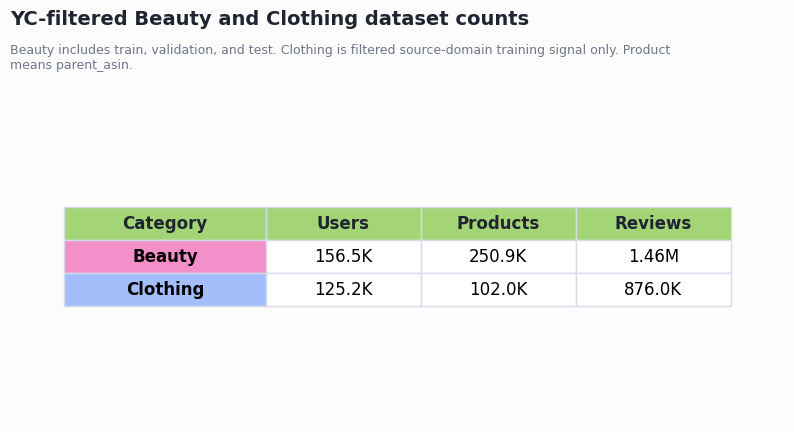

,beauty_only_users,clothing_only_users,both_users,union_users,stage,beauty_only_pct,clothing_only_pct,both_pct
0,24641,0,143736,168377,"After Beauty >=5 user filter, before train vis...",14.6344,0.0,85.3656
1,31331,0,125156,156487,Final YC-filtered training set,20.0215,0.0,79.9785


Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/picture2_user_overlap_post_user_filter.png


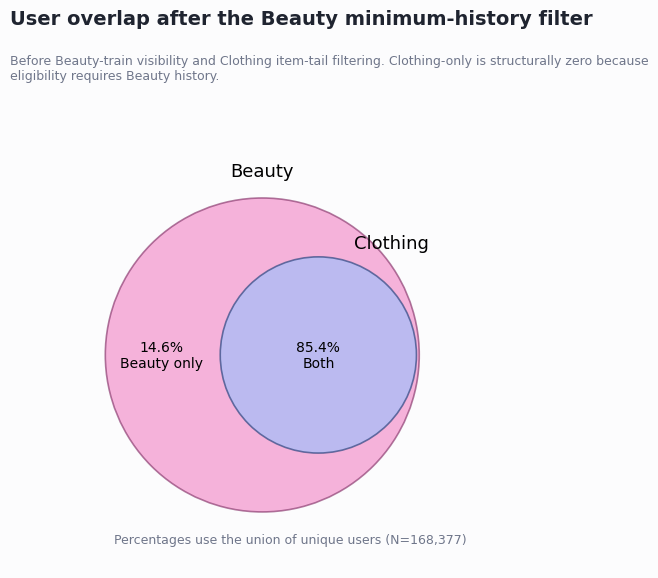

Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/picture2_user_overlap_final_train.png


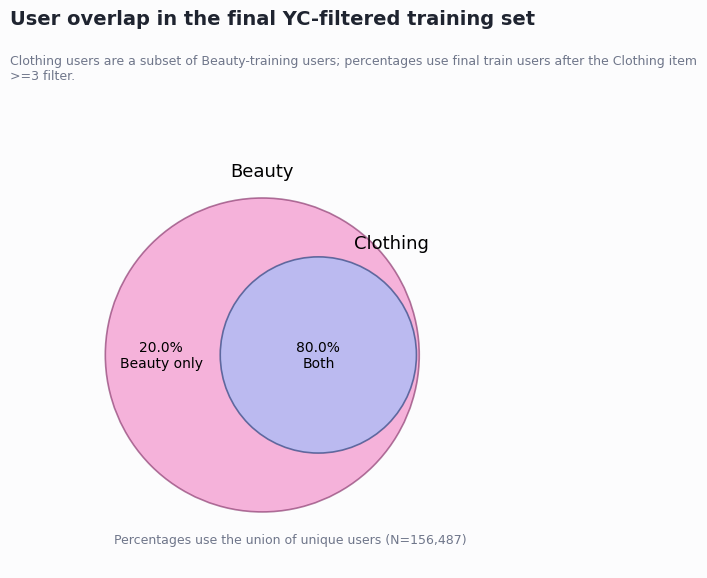

In [9]:
dataset_count_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        category,
        COUNT(DISTINCT user_id) AS unique_users,
        COUNT(DISTINCT parent_asin) AS unique_products,
        COUNT(*) AS reviews
    FROM model_reviews
    GROUP BY category
    ORDER BY
        CASE category
            WHEN ? THEN 1
            WHEN ? THEN 2
            ELSE 3
        END
    """,
    (BEAUTY_CATEGORY, CLOTHING_CATEGORY),
)
dataset_count_df["category_label"] = dataset_count_df["category"].map(
    CATEGORY_LABELS
)
display(dataset_count_df)
dataset_count_df.to_csv(
    OUTPUT_DIR / "picture1_dataset_counts.csv",
    index=False,
)
plot_dataset_count_table(dataset_count_df)


def overlap_summary(
    table_name: str,
    where_sql: str,
    stage: str,
) -> dict[str, Any]:
    query: str = f"""
        WITH user_flags AS (
            SELECT
                user_id,
                MAX(CASE WHEN category = ? THEN 1 ELSE 0 END) AS has_beauty,
                MAX(CASE WHEN category = ? THEN 1 ELSE 0 END)
                    AS has_clothing
            FROM {table_name}
            WHERE {where_sql}
            GROUP BY user_id
        )
        SELECT
            SUM(
                CASE WHEN has_beauty = 1 AND has_clothing = 0
                THEN 1 ELSE 0 END
            ) AS beauty_only_users,
            SUM(
                CASE WHEN has_beauty = 0 AND has_clothing = 1
                THEN 1 ELSE 0 END
            ) AS clothing_only_users,
            SUM(
                CASE WHEN has_beauty = 1 AND has_clothing = 1
                THEN 1 ELSE 0 END
            ) AS both_users,
            COUNT(*) AS union_users
        FROM user_flags
    """
    row: dict[str, Any] = dict(
        dataframe_from_query(
            conn,
            query,
            (BEAUTY_CATEGORY, CLOTHING_CATEGORY),
        ).iloc[0]
    )
    row = {
        key: int(value or 0)
        for key, value in row.items()
    }
    row["stage"] = stage
    union_users: int = int(row["union_users"])
    row["beauty_only_pct"] = round(
        pct(row["beauty_only_users"], union_users),
        4,
    )
    row["clothing_only_pct"] = round(
        pct(row["clothing_only_users"], union_users),
        4,
    )
    row["both_pct"] = round(pct(row["both_users"], union_users), 4)
    return row


post_user_filter_overlap: dict[str, Any] = overlap_summary(
    "user_filtered_reviews",
    "1 = 1",
    "After Beauty >=5 user filter, before train visibility/item tail",
)
final_train_overlap: dict[str, Any] = overlap_summary(
    "model_reviews",
    "split = 'train'",
    "Final YC-filtered training set",
)
overlap_df: pd.DataFrame = pd.DataFrame(
    [post_user_filter_overlap, final_train_overlap]
)
display(overlap_df)
overlap_df.to_csv(
    OUTPUT_DIR / "picture2_user_overlap_percentages.csv",
    index=False,
)

plot_two_set_overlap(
    post_user_filter_overlap,
    "User overlap after the Beauty minimum-history filter",
    (
        "Before Beauty-train visibility and Clothing item-tail filtering. "
        "Clothing-only is structurally zero because eligibility requires "
        "Beauty history."
    ),
    "picture2_user_overlap_post_user_filter",
)
plot_two_set_overlap(
    final_train_overlap,
    "User overlap in the final YC-filtered training set",
    (
        "Clothing users are a subset of Beauty-training users; percentages "
        "use final train users after the Clothing item >=3 filter."
    ),
    "picture2_user_overlap_final_train",
)


,dataset,train_interactions,train_users,train_items,interactions_per_user,sparsity
0,Beauty-only,1125023,156487,215358,7.189243,0.999967
1,Beauty+Clothing,2001046,156487,317363,12.787299,0.999960


Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/cross_category_density_comparison.png


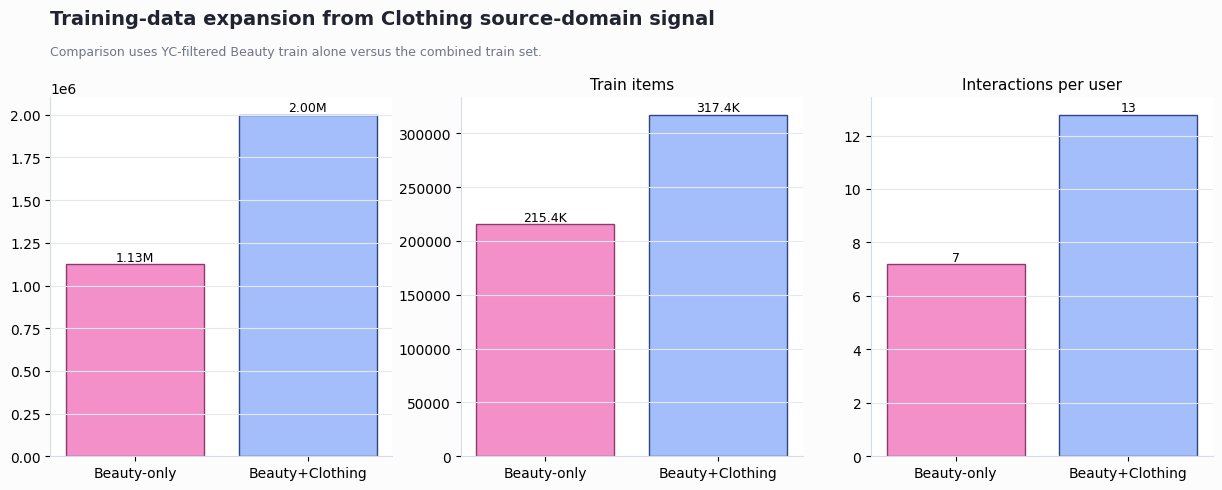

,relationship,users,pearson_r
0,Average user rating: Beauty vs Clothing,143736,0.453170
1,User interaction count: Beauty vs Clothing,143736,0.325354


Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/cross_category_average_rating_hexbin.png


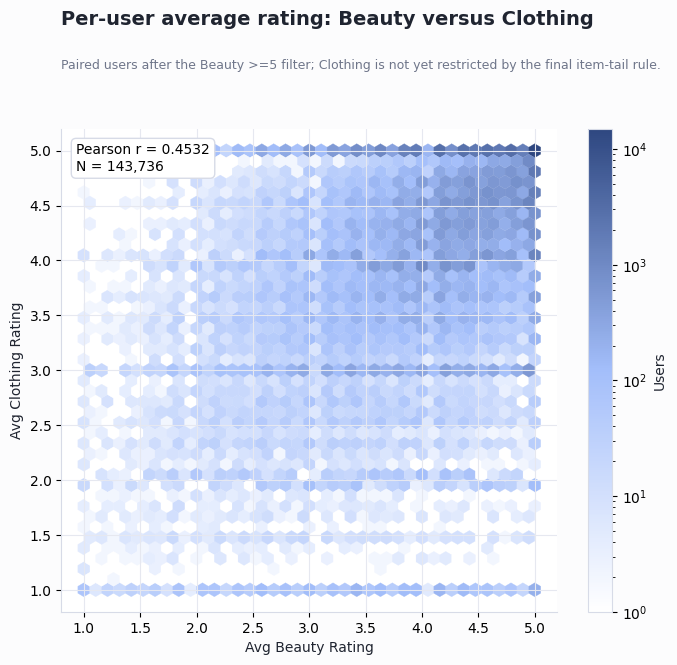

Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/cross_category_activity_hexbin.png


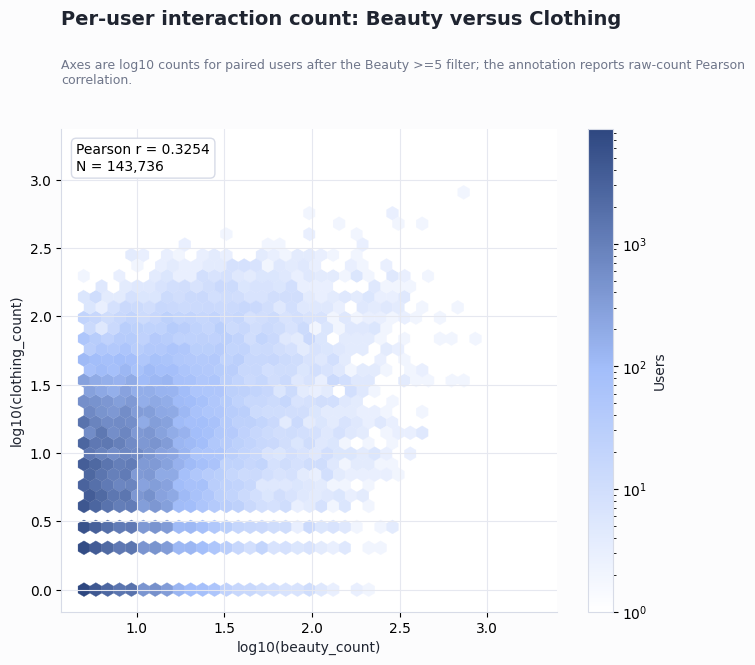

In [10]:
def compute_density_metrics(
    dataset_label: str,
    where_sql: str,
    params: Sequence[Any] = (),
) -> dict[str, Any]:
    row: dict[str, Any] = dict(
        dataframe_from_query(
            conn,
            f"""
            SELECT
                COUNT(*) AS train_interactions,
                COUNT(DISTINCT user_id) AS train_users,
                COUNT(DISTINCT parent_asin) AS train_items
            FROM model_reviews
            WHERE split = 'train' AND ({where_sql})
            """,
            params,
        ).iloc[0]
    )
    train_interactions: int = int(row["train_interactions"] or 0)
    train_users: int = int(row["train_users"] or 0)
    train_items: int = int(row["train_items"] or 0)
    return {
        "dataset": dataset_label,
        "train_interactions": train_interactions,
        "train_users": train_users,
        "train_items": train_items,
        "interactions_per_user": (
            train_interactions / train_users if train_users else 0.0
        ),
        "sparsity": (
            1.0
            - train_interactions / (train_users * train_items)
            if train_users and train_items
            else 1.0
        ),
    }


density_metrics_df: pd.DataFrame = pd.DataFrame(
    [
        compute_density_metrics(
            "Beauty-only",
            "category = ?",
            (BEAUTY_CATEGORY,),
        ),
        compute_density_metrics("Beauty+Clothing", "1 = 1"),
    ]
)
display(density_metrics_df)
density_metrics_df.to_csv(
    OUTPUT_DIR / "cross_category_density_metrics.csv",
    index=False,
)
plot_density_comparison(density_metrics_df)

rating_profile_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        user_id,
        AVG(CASE WHEN category = ? THEN rating END) AS avg_beauty_rating,
        AVG(CASE WHEN category = ? THEN rating END) AS avg_clothing_rating
    FROM user_filtered_reviews
    GROUP BY user_id
    HAVING
        COUNT(CASE WHEN category = ? THEN 1 END) > 0
        AND COUNT(CASE WHEN category = ? THEN 1 END) > 0
    """,
    (
        BEAUTY_CATEGORY,
        CLOTHING_CATEGORY,
        BEAUTY_CATEGORY,
        CLOTHING_CATEGORY,
    ),
)
activity_profile_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        user_id,
        SUM(CASE WHEN category = ? THEN 1 ELSE 0 END) AS beauty_count,
        SUM(CASE WHEN category = ? THEN 1 ELSE 0 END) AS clothing_count
    FROM user_filtered_reviews
    GROUP BY user_id
    HAVING beauty_count > 0 AND clothing_count > 0
    """,
    (BEAUTY_CATEGORY, CLOTHING_CATEGORY),
)

correlation_rows: list[dict[str, Any]] = [
    {
        "relationship": "Average user rating: Beauty vs Clothing",
        "users": len(rating_profile_df),
        "pearson_r": safe_correlation(
            rating_profile_df.get(
                "avg_beauty_rating",
                pd.Series(dtype=float),
            ),
            rating_profile_df.get(
                "avg_clothing_rating",
                pd.Series(dtype=float),
            ),
        ),
    },
    {
        "relationship": "User interaction count: Beauty vs Clothing",
        "users": len(activity_profile_df),
        "pearson_r": safe_correlation(
            activity_profile_df.get(
                "beauty_count",
                pd.Series(dtype=float),
            ),
            activity_profile_df.get(
                "clothing_count",
                pd.Series(dtype=float),
            ),
        ),
    },
]
correlation_df: pd.DataFrame = pd.DataFrame(correlation_rows)
display(correlation_df)
correlation_df.to_csv(
    OUTPUT_DIR / "cross_category_user_correlations.csv",
    index=False,
)

plot_hexbin_relationship(
    rating_profile_df,
    "avg_beauty_rating",
    "avg_clothing_rating",
    "Per-user average rating: Beauty versus Clothing",
    (
        "Paired users after the Beauty >=5 filter; Clothing is not yet "
        "restricted by the final item-tail rule."
    ),
    "cross_category_average_rating_hexbin",
)
plot_hexbin_relationship(
    activity_profile_df,
    "beauty_count",
    "clothing_count",
    "Per-user interaction count: Beauty versus Clothing",
    (
        "Axes are log10 counts for paired users after the Beauty >=5 filter; "
        "the annotation reports raw-count Pearson correlation."
    ),
    "cross_category_activity_hexbin",
    log_scale=True,
)


## Results: EDA 3 - Temporal split and warm/cold diagnostics

- User warmth uses Beauty train interactions only: warm means at least 10.
- Item warmth uses all combined train interactions: warm means at least 5.
- Clothing appears only in train.
- Split dashboards port the companion notebook's user/category, interaction,
  item-warmth, and item/category summaries without loading interaction rows into
  pandas.


In [11]:
split_category_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        split,
        category,
        COUNT(*) AS interactions,
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT parent_asin) AS items
    FROM model_reviews
    GROUP BY split, category
    ORDER BY
        CASE split
            WHEN 'train' THEN 1
            WHEN 'validation' THEN 2
            ELSE 3
        END,
        CASE category
            WHEN ? THEN 1
            WHEN ? THEN 2
            ELSE 3
        END
    """,
    (BEAUTY_CATEGORY, CLOTHING_CATEGORY),
)
split_category_df["category_label"] = split_category_df["category"].map(
    CATEGORY_LABELS
)
display(split_category_df)
split_category_df.to_csv(
    OUTPUT_DIR / "eda3_split_summary_by_category.csv",
    index=False,
)

conn.executescript(
    f"""
    DROP TABLE IF EXISTS user_segments;
    CREATE TABLE user_segments AS
    WITH beauty_train_counts AS (
        SELECT user_id, COUNT(*) AS beauty_train_interactions
        FROM model_reviews
        WHERE
            split = 'train'
            AND category = '{BEAUTY_CATEGORY}'
        GROUP BY user_id
    )
    SELECT
        user_id,
        beauty_train_interactions,
        CASE
            WHEN beauty_train_interactions >= {WARM_USER_MIN_BEAUTY_TRAIN}
                THEN 'warm'
            ELSE 'cold'
        END AS user_segment
    FROM beauty_train_counts;

    CREATE UNIQUE INDEX IF NOT EXISTS idx_user_segments_user
    ON user_segments(user_id);

    DROP TABLE IF EXISTS item_segments;
    CREATE TABLE item_segments AS
    WITH train_counts AS (
        SELECT parent_asin, COUNT(*) AS train_interactions
        FROM model_reviews
        WHERE split = 'train'
        GROUP BY parent_asin
    )
    SELECT
        f.parent_asin,
        f.category,
        COALESCE(t.train_interactions, 0) AS train_interactions,
        CASE
            WHEN COALESCE(t.train_interactions, 0) >= {WARM_ITEM_MIN_TRAIN}
                THEN 'warm'
            ELSE 'cold'
        END AS item_segment
    FROM final_items AS f
    LEFT JOIN train_counts AS t USING(parent_asin);

    CREATE UNIQUE INDEX IF NOT EXISTS idx_item_segments_parent
    ON item_segments(parent_asin);
    """
)
conn.commit()

user_segment_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        user_segment,
        COUNT(*) AS users,
        MIN(beauty_train_interactions) AS min_beauty_train_interactions,
        AVG(beauty_train_interactions) AS mean_beauty_train_interactions,
        MAX(beauty_train_interactions) AS max_beauty_train_interactions
    FROM user_segments
    GROUP BY user_segment
    ORDER BY user_segment DESC
    """,
)
item_segment_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        category,
        item_segment,
        COUNT(*) AS items,
        SUM(CASE WHEN train_interactions = 0 THEN 1 ELSE 0 END)
            AS items_unseen_in_train,
        MIN(train_interactions) AS min_train_interactions,
        AVG(train_interactions) AS mean_train_interactions,
        MAX(train_interactions) AS max_train_interactions
    FROM item_segments
    GROUP BY category, item_segment
    ORDER BY category, item_segment DESC
    """,
)
segment_interaction_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        m.split,
        m.category,
        u.user_segment,
        i.item_segment,
        COUNT(*) AS interactions,
        COUNT(DISTINCT m.user_id) AS users,
        COUNT(DISTINCT m.parent_asin) AS items
    FROM model_reviews AS m
    INNER JOIN user_segments AS u USING(user_id)
    INNER JOIN item_segments AS i USING(parent_asin)
    GROUP BY
        m.split,
        m.category,
        u.user_segment,
        i.item_segment
    ORDER BY
        CASE m.split
            WHEN 'train' THEN 1
            WHEN 'validation' THEN 2
            ELSE 3
        END,
        m.category,
        u.user_segment DESC,
        i.item_segment DESC
    """,
)

display(user_segment_df)
display(item_segment_df)
display(segment_interaction_df)
user_segment_df.to_csv(
    OUTPUT_DIR / "eda3_user_segments.csv",
    index=False,
)
item_segment_df.to_csv(
    OUTPUT_DIR / "eda3_item_segments_by_category.csv",
    index=False,
)
segment_interaction_df.to_csv(
    OUTPUT_DIR / "eda3_warm_cold_interactions_by_split_category.csv",
    index=False,
)


,split,category,interactions,users,items,category_label
0,train,Beauty_and_Personal_Care,1125023,156487,215358,Beauty
1,train,Clothing_Shoes_and_Jewelry,876023,125156,102005,Clothing
2,validation,Beauty_and_Personal_Care,139338,47209,52826,Beauty
3,test,Beauty_and_Personal_Care,197706,55594,66743,Beauty


,user_segment,users,min_beauty_train_interactions,mean_beauty_train_interactions,max_beauty_train_interactions
0,warm,20100,10,21.304726,1546
1,cold,136387,1,5.108977,9


,category,item_segment,items,items_unseen_in_train,min_train_interactions,mean_train_interactions,max_train_interactions
0,Beauty_and_Personal_Care,warm,50483,0,5,16.979498,2353
1,Beauty_and_Personal_Care,cold,200369,35494,0,1.336769,4
2,Clothing_Shoes_and_Jewelry,warm,58458,0,5,12.466848,6444
3,Clothing_Shoes_and_Jewelry,cold,43547,0,3,3.381083,4


,split,category,user_segment,item_segment,interactions,users,items
0,train,Beauty_and_Personal_Care,warm,warm,335188,20096,47374
1,train,Beauty_and_Personal_Care,warm,cold,93037,18574,69873
2,train,Beauty_and_Personal_Care,cold,warm,521988,133199,43931
3,train,Beauty_and_Personal_Care,cold,cold,174810,93591,123660
4,train,Clothing_Shoes_and_Jewelry,warm,warm,213200,17170,52031
5,train,Clothing_Shoes_and_Jewelry,warm,cold,47975,11020,28225
6,train,Clothing_Shoes_and_Jewelry,cold,warm,515587,103062,57036
7,train,Clothing_Shoes_and_Jewelry,cold,cold,99261,50530,39877
8,validation,Beauty_and_Personal_Care,warm,warm,18303,5563,9575
9,validation,Beauty_and_Personal_Care,warm,cold,22552,4064,9300


Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/eda3_train_composition.png


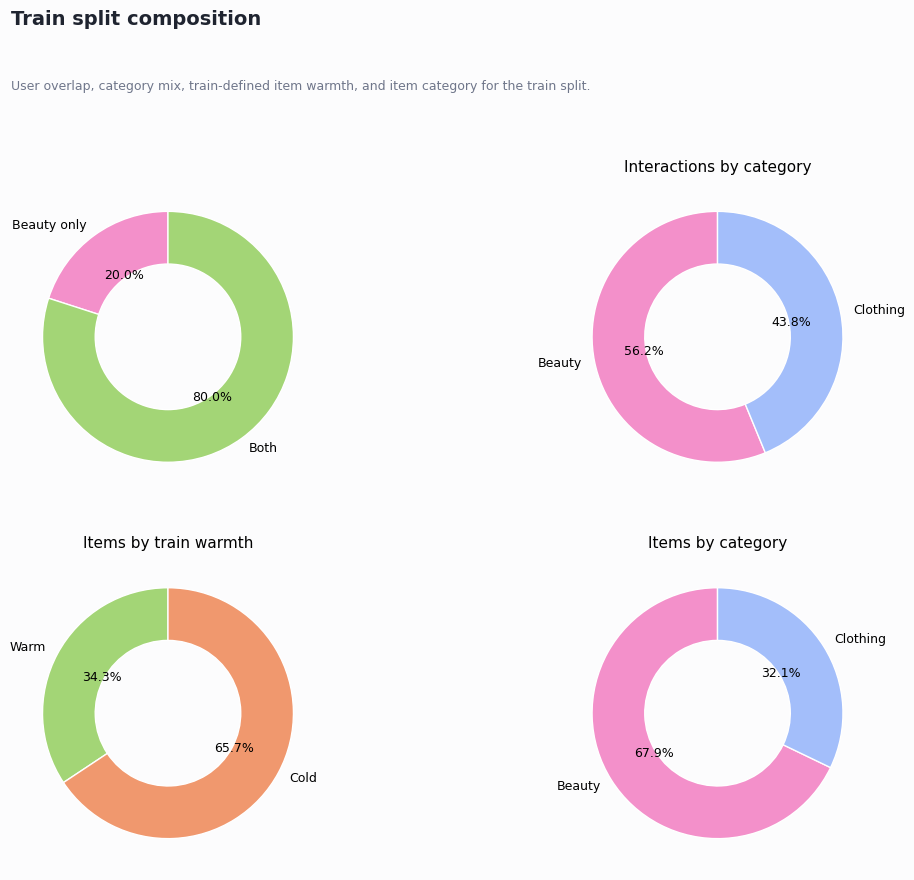

Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/eda3_validation_composition.png


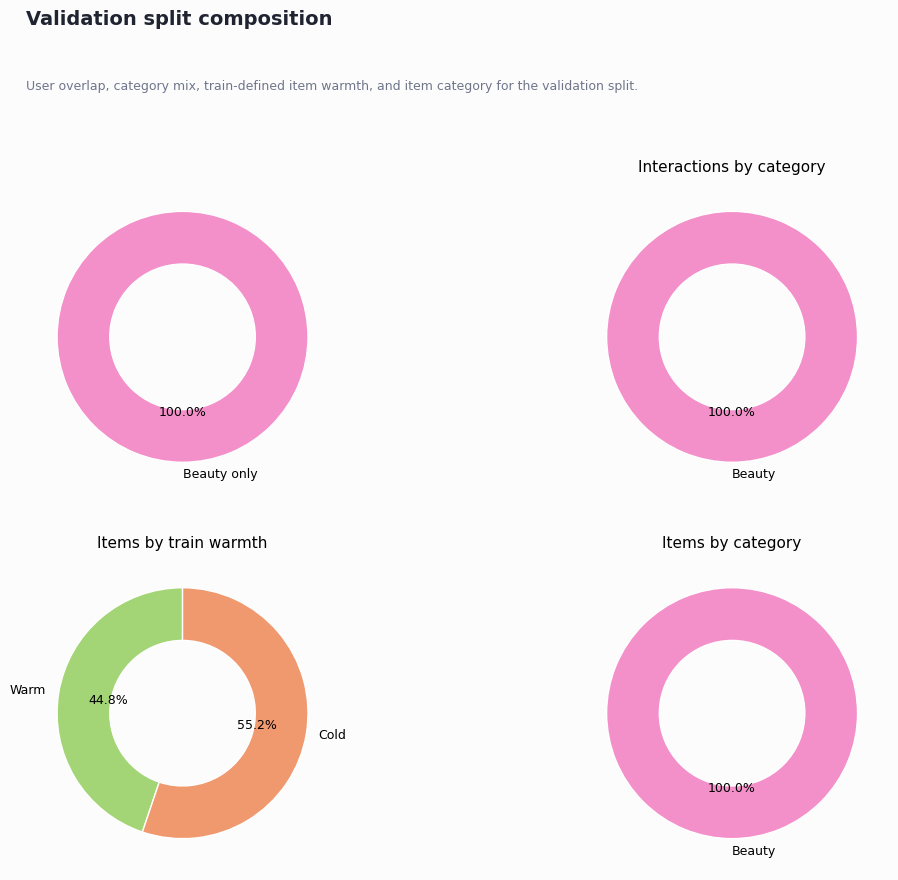

Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/eda3_test_composition.png


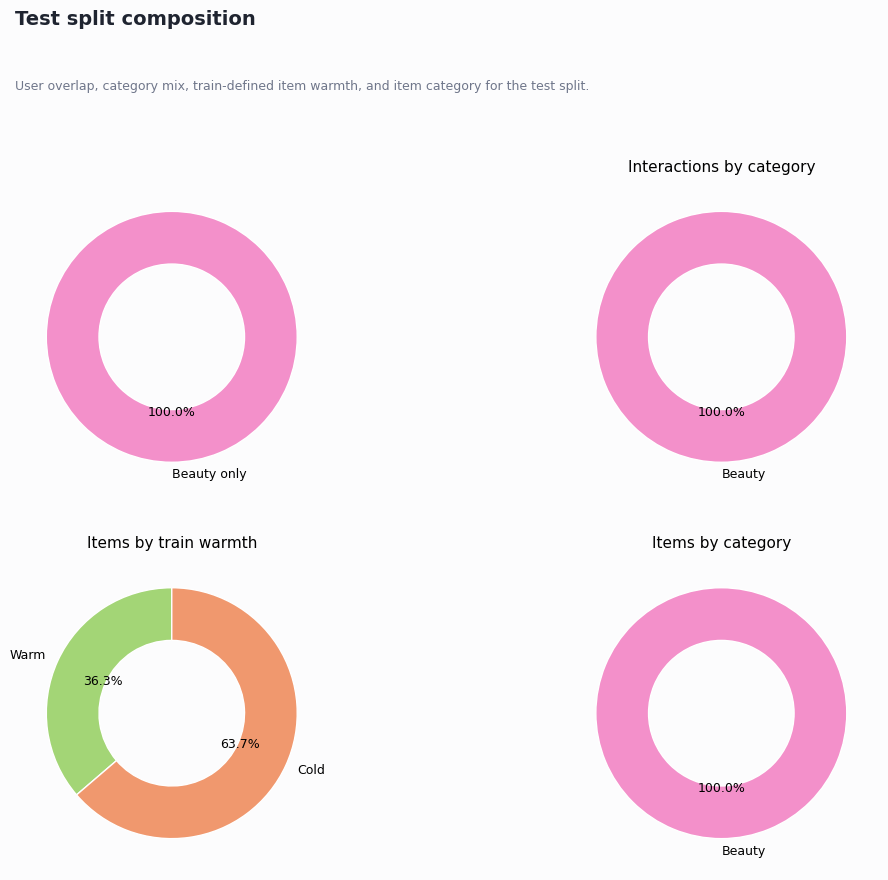

,split,metric,value
0,Train,users,156487
1,Train,items,317363
2,Train,interactions,2001046
3,Train,beauty_only_users,31331
4,Train,both_category_users,125156
5,Train,clothing_only_users,0
6,Train,beauty_interactions,1125023
7,Train,clothing_interactions,876023
8,Train,beauty_items,215358
9,Train,clothing_items,102005


In [12]:
def plot_donut(
    ax: plt.Axes,
    values: Sequence[int],
    labels: Sequence[str],
    colors: Sequence[str],
    title: str,
) -> None:
    positive_entries: list[tuple[int, str, str]] = [
        (int(value), str(label), str(color))
        for value, label, color in zip(values, labels, colors)
        if int(value) > 0
    ]
    clean_values: list[int] = [entry[0] for entry in positive_entries]
    if sum(clean_values) == 0:
        ax.text(0.5, 0.5, "No rows", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        return
    ax.pie(
        clean_values,
        labels=[entry[1] for entry in positive_entries],
        autopct=lambda value: f"{value:.1f}%" if value > 0 else "",
        colors=[entry[2] for entry in positive_entries],
        startangle=90,
        wedgeprops={
            "width": 0.42,
            "edgecolor": TOKENS["panel"],
            "linewidth": 1.0,
        },
        textprops={"fontsize": 9},
    )
    ax.set_title(title, fontsize=11)


def analyze_user_segment(
    split_label: str,
    split_value: str,
) -> pd.DataFrame:
    overall: dict[str, Any] = dict(
        dataframe_from_query(
            conn,
            """
            SELECT
                COUNT(*) AS interactions,
                COUNT(DISTINCT user_id) AS users,
                COUNT(DISTINCT parent_asin) AS items
            FROM model_reviews
            WHERE split = ?
            """,
            (split_value,),
        ).iloc[0]
    )
    user_overlap: dict[str, Any] = overlap_summary(
        "model_reviews",
        f"split = '{split_value}'",
        split_label,
    )
    category_counts: pd.DataFrame = dataframe_from_query(
        conn,
        """
        SELECT
            category,
            COUNT(*) AS interactions,
            COUNT(DISTINCT parent_asin) AS items
        FROM model_reviews
        WHERE split = ?
        GROUP BY category
        """,
        (split_value,),
    )
    warmth_counts: pd.DataFrame = dataframe_from_query(
        conn,
        """
        SELECT
            i.item_segment,
            COUNT(DISTINCT m.parent_asin) AS items
        FROM model_reviews AS m
        INNER JOIN item_segments AS i USING(parent_asin)
        WHERE m.split = ?
        GROUP BY i.item_segment
        """,
        (split_value,),
    )

    def category_value(category: str, column: str) -> int:
        match: pd.DataFrame = category_counts[
            category_counts["category"] == category
        ]
        return int(match[column].iloc[0]) if not match.empty else 0

    def warmth_value(segment: str) -> int:
        match: pd.DataFrame = warmth_counts[
            warmth_counts["item_segment"] == segment
        ]
        return int(match["items"].iloc[0]) if not match.empty else 0

    summary_rows: list[dict[str, Any]] = [
        {
            "split": split_label,
            "metric": "users",
            "value": int(overall["users"] or 0),
        },
        {
            "split": split_label,
            "metric": "items",
            "value": int(overall["items"] or 0),
        },
        {
            "split": split_label,
            "metric": "interactions",
            "value": int(overall["interactions"] or 0),
        },
        {
            "split": split_label,
            "metric": "beauty_only_users",
            "value": int(user_overlap["beauty_only_users"]),
        },
        {
            "split": split_label,
            "metric": "both_category_users",
            "value": int(user_overlap["both_users"]),
        },
        {
            "split": split_label,
            "metric": "clothing_only_users",
            "value": int(user_overlap["clothing_only_users"]),
        },
        {
            "split": split_label,
            "metric": "beauty_interactions",
            "value": category_value(BEAUTY_CATEGORY, "interactions"),
        },
        {
            "split": split_label,
            "metric": "clothing_interactions",
            "value": category_value(CLOTHING_CATEGORY, "interactions"),
        },
        {
            "split": split_label,
            "metric": "beauty_items",
            "value": category_value(BEAUTY_CATEGORY, "items"),
        },
        {
            "split": split_label,
            "metric": "clothing_items",
            "value": category_value(CLOTHING_CATEGORY, "items"),
        },
        {
            "split": split_label,
            "metric": "warm_items",
            "value": warmth_value("warm"),
        },
        {
            "split": split_label,
            "metric": "cold_items",
            "value": warmth_value("cold"),
        },
    ]
    summary_df: pd.DataFrame = pd.DataFrame(summary_rows)

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    plot_donut(
        axes[0, 0],
        [
            int(user_overlap["beauty_only_users"]),
            int(user_overlap["both_users"]),
            int(user_overlap["clothing_only_users"]),
        ],
        ["Beauty only", "Both", "Clothing only"],
        [TOKENS["beauty"], TOKENS["olive"], TOKENS["clothing"]],
        "Users by category",
    )
    plot_donut(
        axes[0, 1],
        [
            category_value(BEAUTY_CATEGORY, "interactions"),
            category_value(CLOTHING_CATEGORY, "interactions"),
        ],
        ["Beauty", "Clothing"],
        [TOKENS["beauty"], TOKENS["clothing"]],
        "Interactions by category",
    )
    plot_donut(
        axes[1, 0],
        [warmth_value("warm"), warmth_value("cold")],
        ["Warm", "Cold"],
        [TOKENS["olive"], TOKENS["orange"]],
        "Items by train warmth",
    )
    plot_donut(
        axes[1, 1],
        [
            category_value(BEAUTY_CATEGORY, "items"),
            category_value(CLOTHING_CATEGORY, "items"),
        ],
        ["Beauty", "Clothing"],
        [TOKENS["beauty"], TOKENS["clothing"]],
        "Items by category",
    )
    add_chart_header(
        fig,
        axes[0, 0],
        f"{split_label} split composition",
        (
            "User overlap, category mix, train-defined item warmth, and item "
            f"category for the {split_label.lower()} split."
        ),
    )
    save_figure(fig, f"eda3_{split_value}_composition")
    plt.show()
    return summary_df


split_dashboard_frames: list[pd.DataFrame] = []
for split_label, split_value in [
    ("Train", "train"),
    ("Validation", "validation"),
    ("Test", "test"),
]:
    frame: pd.DataFrame = analyze_user_segment(split_label, split_value)
    split_dashboard_frames.append(frame)

split_dashboard_df: pd.DataFrame = pd.concat(
    split_dashboard_frames,
    ignore_index=True,
)
display(split_dashboard_df)
split_dashboard_df.to_csv(
    OUTPUT_DIR / "eda3_split_composition_metrics.csv",
    index=False,
)


## Results: EDA 4 - Metadata, text, image, category, and price readiness

The key metadata-readiness fields are:

- `null_title_pct_of_metadata`
- `null_or_empty_images_pct_of_metadata`
- `no_usable_image_url_pct_of_metadata`

The second metric checks whether the raw `images` field is absent or empty. The
third is stricter and checks whether any supported product-image URL is usable.


,0,1,2
category_label,Beauty,Clothing,Combined
final_review_items,250852,102005,352857
items_with_metadata,250852,102005,352857
metadata_coverage_pct,100.0,100.0,100.0
null_title_pct_of_metadata,0.0028,0.0039,0.0031
null_features_pct_of_metadata,19.2624,0.9637,13.9725
null_description_pct_of_metadata,55.6603,70.3828,59.9163
null_price_pct_of_metadata,40.9397,10.1446,32.0373
null_or_empty_images_pct_of_metadata,0.0016,0.0039,0.0023
no_usable_image_url_pct_of_metadata,0.0016,0.0039,0.0023


Figure saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/metadata_title_image_null_rates.png


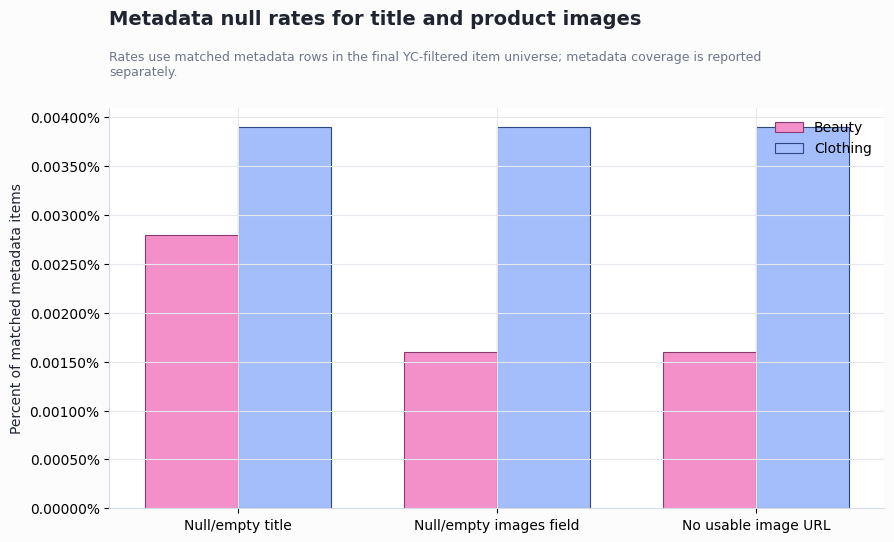

,source_category,main_category,count,category_label,pct
0,Beauty_and_Personal_Care,All Beauty,192059,Beauty,76.562674
1,Beauty_and_Personal_Care,Health & Personal Care,17714,Beauty,7.061534
2,Beauty_and_Personal_Care,Premium Beauty,10807,Beauty,4.308118
3,Beauty_and_Personal_Care,(null),10157,Beauty,4.049001
4,Beauty_and_Personal_Care,Amazon Home,9285,Beauty,3.701386
5,Beauty_and_Personal_Care,Tools & Home Improvement,4405,Beauty,1.756015
6,Beauty_and_Personal_Care,AMAZON FASHION,2366,Beauty,0.943186
7,Beauty_and_Personal_Care,Industrial & Scientific,1451,Beauty,0.578429
8,Beauty_and_Personal_Care,Grocery,456,Beauty,0.181780
9,Beauty_and_Personal_Care,"Arts, Crafts & Sewing",418,Beauty,0.166632


,source_category,first_category,count,category_label,pct
0,Beauty_and_Personal_Care,Beauty & Personal Care,250852,Beauty,100.000000
1,Clothing_Shoes_and_Jewelry,"Clothing, Shoes & Jewelry",101894,Clothing,99.891182
2,Clothing_Shoes_and_Jewelry,"Shoe, Jewelry & Watch Accessories",111,Clothing,0.108818


In [13]:
def metadata_summary_for_category(
    category_label: str,
    category_value: str | None,
) -> dict[str, Any]:
    where_clause: str = "1 = 1" if category_value is None else "f.category = ?"
    params: tuple[Any, ...] = () if category_value is None else (category_value,)
    aggregate: dict[str, Any] = dict(
        dataframe_from_query(
            conn,
            f"""
            SELECT
                COUNT(*) AS final_review_items,
                SUM(CASE WHEN m.parent_asin IS NOT NULL THEN 1 ELSE 0 END)
                    AS items_with_metadata,
                SUM(CASE WHEN m.empty_title = 1 THEN 1 ELSE 0 END)
                    AS empty_title,
                SUM(CASE WHEN m.empty_features = 1 THEN 1 ELSE 0 END)
                    AS empty_features,
                SUM(CASE WHEN m.empty_description = 1 THEN 1 ELSE 0 END)
                    AS empty_description,
                SUM(CASE WHEN m.empty_price = 1 THEN 1 ELSE 0 END)
                    AS empty_price,
                SUM(CASE WHEN m.empty_images_field = 1 THEN 1 ELSE 0 END)
                    AS empty_images_field,
                SUM(CASE WHEN m.usable_image = 0 THEN 1 ELSE 0 END)
                    AS no_usable_image,
                SUM(CASE WHEN m.embedding_text_available = 1 THEN 1 ELSE 0 END)
                    AS embedding_text_available
            FROM final_items AS f
            LEFT JOIN matched_metadata AS m USING(parent_asin)
            WHERE {where_clause}
            """,
            params,
        ).iloc[0]
    )
    final_items: int = int(aggregate["final_review_items"] or 0)
    metadata_items: int = int(aggregate["items_with_metadata"] or 0)
    text_lengths: pd.DataFrame = dataframe_from_query(
        conn,
        f"""
        SELECT m.text_length
        FROM final_items AS f
        INNER JOIN matched_metadata AS m USING(parent_asin)
        WHERE
            {where_clause}
            AND m.embedding_text_available = 1
        """,
        params,
    )
    text_distribution: dict[str, float | int] = distribution_summary(
        text_lengths["text_length"]
        if "text_length" in text_lengths
        else pd.Series(dtype=float)
    )
    return {
        "category_label": category_label,
        "final_review_items": final_items,
        "items_with_metadata": metadata_items,
        "metadata_coverage_pct": round(
            pct(metadata_items, final_items),
            4,
        ),
        "null_title_pct_of_metadata": round(
            pct(int(aggregate["empty_title"] or 0), metadata_items),
            4,
        ),
        "null_features_pct_of_metadata": round(
            pct(int(aggregate["empty_features"] or 0), metadata_items),
            4,
        ),
        "null_description_pct_of_metadata": round(
            pct(int(aggregate["empty_description"] or 0), metadata_items),
            4,
        ),
        "null_price_pct_of_metadata": round(
            pct(int(aggregate["empty_price"] or 0), metadata_items),
            4,
        ),
        "null_or_empty_images_pct_of_metadata": round(
            pct(
                int(aggregate["empty_images_field"] or 0),
                metadata_items,
            ),
            4,
        ),
        "no_usable_image_url_pct_of_metadata": round(
            pct(int(aggregate["no_usable_image"] or 0), metadata_items),
            4,
        ),
        "embedding_text_available_pct": round(
            pct(
                int(aggregate["embedding_text_available"] or 0),
                metadata_items,
            ),
            4,
        ),
        "combined_text_length_median": text_distribution["median"],
        "combined_text_length_p90": text_distribution["p90"],
        "combined_text_length_p99": text_distribution["p99"],
    }


metadata_readiness_rows: list[dict[str, Any]] = [
    metadata_summary_for_category("Beauty", BEAUTY_CATEGORY),
    metadata_summary_for_category("Clothing", CLOTHING_CATEGORY),
    metadata_summary_for_category("Combined", None),
]
metadata_readiness_df: pd.DataFrame = pd.DataFrame(
    metadata_readiness_rows
)
display(metadata_readiness_df.T)
metadata_readiness_df.to_csv(
    OUTPUT_DIR / "eda4_metadata_readiness_by_category.csv",
    index=False,
)
plot_null_rates(metadata_readiness_df)

main_category_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        source_category,
        COALESCE(main_category, '(null)') AS main_category,
        COUNT(*) AS count
    FROM matched_metadata
    GROUP BY source_category, COALESCE(main_category, '(null)')
    ORDER BY source_category, count DESC, main_category
    """,
)
first_category_df: pd.DataFrame = dataframe_from_query(
    conn,
    """
    SELECT
        source_category,
        COALESCE(first_category, '(null)') AS first_category,
        COUNT(*) AS count
    FROM matched_metadata
    GROUP BY source_category, COALESCE(first_category, '(null)')
    ORDER BY source_category, count DESC, first_category
    """,
)
for frame in [main_category_df, first_category_df]:
    frame["category_label"] = frame["source_category"].map(CATEGORY_LABELS)
    totals: pd.Series = frame.groupby("source_category")["count"].transform(
        "sum"
    )
    frame["pct"] = 100.0 * frame["count"] / totals

display(main_category_df.groupby("source_category").head(15))
display(first_category_df.groupby("source_category").head(15))
main_category_df.to_csv(
    OUTPUT_DIR / "eda4_main_category_distribution.csv",
    index=False,
)
first_category_df.to_csv(
    OUTPUT_DIR / "eda4_first_category_distribution.csv",
    index=False,
)


## Takeaways and checks

The following cell validates full-run counts, writes a compact run-summary CSV,
and lists generated evidence files. Conclusions should be drawn from the executed
tables rather than unexecuted notebook text.


In [14]:
actual_counts: dict[str, int] = {
    "beauty_train": scalar_from_query(
        conn,
        """
        SELECT COUNT(*) FROM model_reviews
        WHERE category = ? AND split = 'train'
        """,
        (BEAUTY_CATEGORY,),
    ),
    "beauty_validation": scalar_from_query(
        conn,
        """
        SELECT COUNT(*) FROM model_reviews
        WHERE category = ? AND split = 'validation'
        """,
        (BEAUTY_CATEGORY,),
    ),
    "beauty_test": scalar_from_query(
        conn,
        """
        SELECT COUNT(*) FROM model_reviews
        WHERE category = ? AND split = 'test'
        """,
        (BEAUTY_CATEGORY,),
    ),
    "clothing_train": scalar_from_query(
        conn,
        """
        SELECT COUNT(*) FROM model_reviews
        WHERE category = ? AND split = 'train'
        """,
        (CLOTHING_CATEGORY,),
    ),
    "combined_train": scalar_from_query(
        conn,
        "SELECT COUNT(*) FROM model_reviews WHERE split = 'train'",
    ),
    "combined_total": scalar_from_query(
        conn,
        "SELECT COUNT(*) FROM model_reviews",
    ),
}
validation_rows: list[dict[str, Any]] = [
    {
        "metric": metric,
        "actual": actual_counts[metric],
        "expected": expected,
        "difference": actual_counts[metric] - expected,
    }
    for metric, expected in EXPECTED_COUNTS.items()
]
validation_df: pd.DataFrame = pd.DataFrame(validation_rows)
display(validation_df)
validation_df.to_csv(
    OUTPUT_DIR / "canonical_count_validation.csv",
    index=False,
)

canonical_run: bool = (
    MAX_REVIEW_ROWS_PER_FILE is None
    and MAX_META_ROWS_PER_FILE is None
    and USER_MIN_BEAUTY_INTERACTIONS == 5
    and CLOTHING_MIN_TRAIN_INTERACTIONS == 3
    and WARM_USER_MIN_BEAUTY_TRAIN == 10
    and WARM_ITEM_MIN_TRAIN == 5
)
all_counts_match: bool = bool(
    (validation_df["difference"] == 0).all()
)
if canonical_run:
    validation_message: str = (
        "PASS: all canonical interaction counts match YC's saved dataset."
        if all_counts_match
        else (
            "WARNING: canonical interaction counts do not all match YC's "
            "saved dataset."
        )
    )
    print(validation_message)
    if STRICT_EXPECTED_COUNTS and not all_counts_match:
        raise AssertionError(validation_message)
else:
    print("Canonical count assertion skipped for capped or modified run.")

run_summary_rows: list[dict[str, Any]] = [
    {
        "topic": "Method",
        "finding": (
            "Clothing is training-only source-domain signal from Beauty-train "
            "users; item minimum is 3 selected Clothing interactions."
        ),
    },
    {
        "topic": "Date boundary",
        "finding": (
            "END_DATE is interpreted exactly as 2022-12-31 00:00:00 UTC, "
            "matching YC's code."
        ),
    },
    {
        "topic": "Temporal caveat",
        "finding": (
            "Selected Clothing interactions after the Beauty train cutoff "
            "still enter training under YC's implementation."
        ),
    },
    {
        "topic": "Metadata denominator",
        "finding": (
            "Title/image null rates use matched metadata rows; missing "
            "metadata coverage is reported separately."
        ),
    },
]
write_csv(
    OUTPUT_DIR / "run_method_summary.csv",
    run_summary_rows,
    ["topic", "finding"],
)

print("\nEDA complete.")
print("Output directory:", OUTPUT_DIR)
print("Generated CSV files:")
for output_path in sorted(OUTPUT_DIR.glob("*.csv")):
    print(
        f"- {output_path.name} "
        f"({output_path.stat().st_size / 1024:.1f} KB)"
    )
print("\nGenerated figures:")
for output_path in sorted(OUTPUT_DIR.glob("*.png")):
    print(
        f"- {output_path.name} "
        f"({output_path.stat().st_size / 1024:.1f} KB)"
    )
print("\nCache files:")
for cache_path in (
    DB_PATH,
    FILTER_MANIFEST_PATH,
    METADATA_MANIFEST_PATH,
):
    if cache_path.exists():
        print(
            f"- {cache_path.name} "
            f"({cache_path.stat().st_size / 1024 / 1024:.1f} MB)"
        )

gc.collect()


,metric,actual,expected,difference
0,beauty_train,1125023,1125023,0
1,beauty_validation,139338,139338,0
2,beauty_test,197706,197706,0
3,clothing_train,876023,876023,0
4,combined_train,2001046,2001046,0
5,combined_total,2338090,2338090,0


PASS: all canonical interaction counts match YC's saved dataset.
CSV saved: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing/run_method_summary.csv (4 rows)

EDA complete.
Output directory: /Users/frankwang1224/Projects/rcd_sys_proj02/eda_outputs_yc_filtered_beauty_clothing
Generated CSV files:
- canonical_count_validation.csv (0.2 KB)
- clothing_item_tail_before_min3_filter.csv (0.1 KB)
- cross_category_density_metrics.csv (0.2 KB)
- cross_category_user_correlations.csv (0.2 KB)
- eda1_asin_multi_parent_asin.csv (0.0 KB)
- eda1_cross_category_parent_asin.csv (0.0 KB)
- eda1_integrity_summary.csv (0.8 KB)
- eda2_rating_distribution_by_category.csv (0.6 KB)
- eda2_shape_sparsity_by_category.csv (0.7 KB)
- eda3_item_segments_by_category.csv (0.4 KB)
- eda3_split_composition_metrics.csv (1.0 KB)
- eda3_split_summary_by_category.csv (0.3 KB)
- eda3_user_segments.csv (0.2 KB)
- eda3_warm_cold_interactions_by_split_category.csv (1.0 KB)
- eda4_first_catego

36314